# 2023 Global Prosperity Index Analysis - David Custer - STAT 531

## Table of Contents:
- ### [Homework 1](#hw1)
  - #### [Packages](#packages)
  - #### [Introduction](#intro)
  - #### [Data Wrangling](#dat.wrangle)
  - #### [Countries per Region](#regions)
  - #### [Preliminary Visualizations](#prelim.visuals)
  - #### [Dimensionality Reduction via Principal Components Analysis (PCA)](#pca)
    - ##### [Scree Plot](#scree)
    - ##### [PC Loadings](#pc.loadings)
    - ##### [PC Scores](#pc.scores)
    - ##### [Interactive 3-D Plot of PC Scores](#interactive.pc.scores)
- ### [Homework 2](#hw2)
  - #### [Canonical Correlation Analysis (CCA)](#cca)
    - ##### [Scatterplot Matrix](#scatterplot.matrix)
    - ##### [CCA with each Domain of Prosperity](#cca.plots)
  - #### [Assessing Normality](#normality)
    - ##### [Histograms of Variables](#histograms)
    - ##### [Normal Quantile-Quantile Plots](#qqplots)
  - #### [K-Nearest Neighbors](#knn)
  - #### [LASSO](#lasso)
- ### [Homework 3](#hw3)
  - #### [XGBoost](#xgb)
    - ##### [Retraining XGBoost for Regime Classification](#xgbclassification)
    - ##### [Retraining XGBoost for Regime Probability](#xgbprobability)
- ### [Homework 4](#hw4)
  - #### [Receiver Operating Characteristic (ROC) Curve](#roc)

## Homework 1 <a name="hw1" /> 

### Packages <a name="packages" /> 

In [102]:
%pip install --upgrade pip
%pip install --quiet matplotlib notebook numpy pandas plotly scikit-learn seaborn xgboost 2>nul

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [103]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, auc, classification_report, mean_squared_error, roc_curve, roc_auc_score
from sklearn.linear_model import Lasso, LassoCV, LogisticRegression
from sklearn.neural_network import MLPClassifier
from IPython.display import IFrame, display, HTML
from xgboost import XGBClassifier

### Introduction <a name="intro" /> 

In [104]:
png_path = (r"C:\Users\anon\Python Files\STAT 531\Angel_Prosperity.png")

html_code = f'''
<style>
    /* Remove default margins and padding */
    body {{
        margin: 0;
        padding: 0;
    }}

    /* Full-page embedded PDF */
    .pdf-container {{
        width: 100%;
        height: 100vh;  /* Take up full viewport height */
        border: none;
    }}
</style>
<iframe class="pdf-container" src="{png_path}"></iframe>
'''

display(HTML(html_code))

### Data Wrangling <a name="dat.wrangle" /> 

In [105]:
prosperity_ranks = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\2023globalpropserity.csv")
display(prosperity_ranks) # We want to extract the relevant political regimes and regions.

,country,code,region,political_regime,prosperity_rank,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,DNK,Europe,Liberal Democracy,6.00,6,2,3,1,8,8,9,7,2,16,5,5
1,Sweden,SWE,Europe,Liberal Democracy,6.83,10,4,7,4,6,15,7,8,3,9,8,1
2,Norway,NOR,Europe,Liberal Democracy,7.25,3,1,2,3,9,14,20,5,4,7,10,9
3,Finland,FIN,Europe,Liberal Democracy,8.00,15,3,1,7,2,12,10,20,7,15,2,2
4,Switzerland,CHE,Europe,Liberal Democracy,6.75,2,12,4,12,12,1,11,2,5,10,4,6
5,Netherlands,NLD,Europe,Liberal Democracy,9.08,9,5,5,8,3,9,3,10,1,11,6,39
6,Luxembourg,LUX,Europe,Liberal Democracy,11.09,1,6,8,18,20,4,6,6,6,12,36,10
7,Iceland,ISL,Europe,Liberal Democracy,12.59,8,7,10,5,19,20,19,21,10,8,11,13
8,Germany,DEU,Europe,Liberal Democracy,12.66,19,9,9,20,21,6,5,11,8,13,19,12
9,New Zealand,NZL,Oceania,Liberal Democracy,17.33,32,11,6,2,7,21,23,22,30,25,18,11


In [106]:
pd.set_option("display.max_rows", 10)
prosperity_scores = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\data.csv")
display(prosperity_scores)

# check for missing values

pd.set_option("display.max_rows", 20)
prosperity_scores.isnull().sum() # no more missing values

,country,region,political_regime,prosperity_score,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,Europe,Liberal Democracy,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94
1,Sweden,Europe,Liberal Democracy,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74
2,Norway,Europe,Liberal Democracy,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37
3,Finland,Europe,Liberal Democracy,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99
4,Switzerland,Europe,Liberal Democracy,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Somalia,Africa,Closed Autocracy,34.39,31.91,34.32,23.80,43.50,31.16,41.79,26.75,28.23,32.07,44.38,26.32,48.46
163,Afghanistan,Asia,Closed Autocracy,34.18,20.93,31.02,29.47,31.17,30.25,42.01,29.67,33.75,39.74,50.91,27.11,44.11
164,Central African Republic,Africa,Electoral Autocracy,32.83,35.30,36.83,28.40,36.72,26.32,40.21,25.49,40.34,19.21,31.95,18.62,54.57
165,Yemen,Middle East,Closed Autocracy,32.65,22.60,25.30,18.20,38.44,22.76,33.12,30.93,28.81,41.58,57.45,28.12,44.49


country                             0
region                              0
political_regime                    0
prosperity_score                    0
safety_and_security                 0
personal_freedom                    0
governance                          0
social_capital                      0
investment_environment              0
enterprise_conditions               0
infrastructure_and_market_access    0
economic_quality                    0
living_conditions                   0
health                              0
education                           0
natural_environment                 0
dtype: int64

### Countries per Region <a name="regions" /> 

In [107]:
country_region_df = prosperity_scores[["country", "region"]]
grouped = country_region_df.groupby("region")["country"].apply(list).reset_index()
grouped["country"] = grouped["country"].apply(sorted)
grouped = grouped.sort_values("region")
max_len = max(grouped["country"].apply(len))
data = {region: countries + [""] * (max_len - len(countries)) for region, 
        countries in zip(grouped["region"], grouped["country"])}
regions_df = pd.DataFrame(data)
sorted_regions_df = regions_df.sort_index(axis=1)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 1000)
display(sorted_regions_df)

,Africa,Asia,Caribbean,Central America,Europe,Middle East,North America,Oceania,South America
0,Algeria,Afghanistan,Cuba,Belize,Albania,Armenia,Canada,Australia,Argentina
1,Angola,Bangladesh,Dominican Republic,Costa Rica,Austria,Azerbaijan,Mexico,New Zealand,Bolivia
2,Benin,Cambodia,Haiti,El Salvador,Belarus,Bahrain,United States,Papua New Guinea,Brazil
3,Botswana,China,Jamaica,Guatemala,Belgium,Georgia,,,Chile
4,Burkina Faso,Hong Kong,Trinidad and Tobago,Honduras,Bosnia and Herzegovina,Iran,,,Colombia
5,Burundi,India,,Nicaragua,Bulgaria,Iraq,,,Ecuador
6,Cabo Verde,Indonesia,,Panama,Croatia,Israel,,,Guyana
7,Cameroon,Japan,,,Cyprus,Jordan,,,Paraguay
8,Central African Republic,Kazakhstan,,,Czech Republic,Kuwait,,,Peru
9,Chad,Kyrgyzstan,,,Denmark,Lebanon,,,Suriname


### Preliminary Visualizations <a name="prelim.visuals" /> 

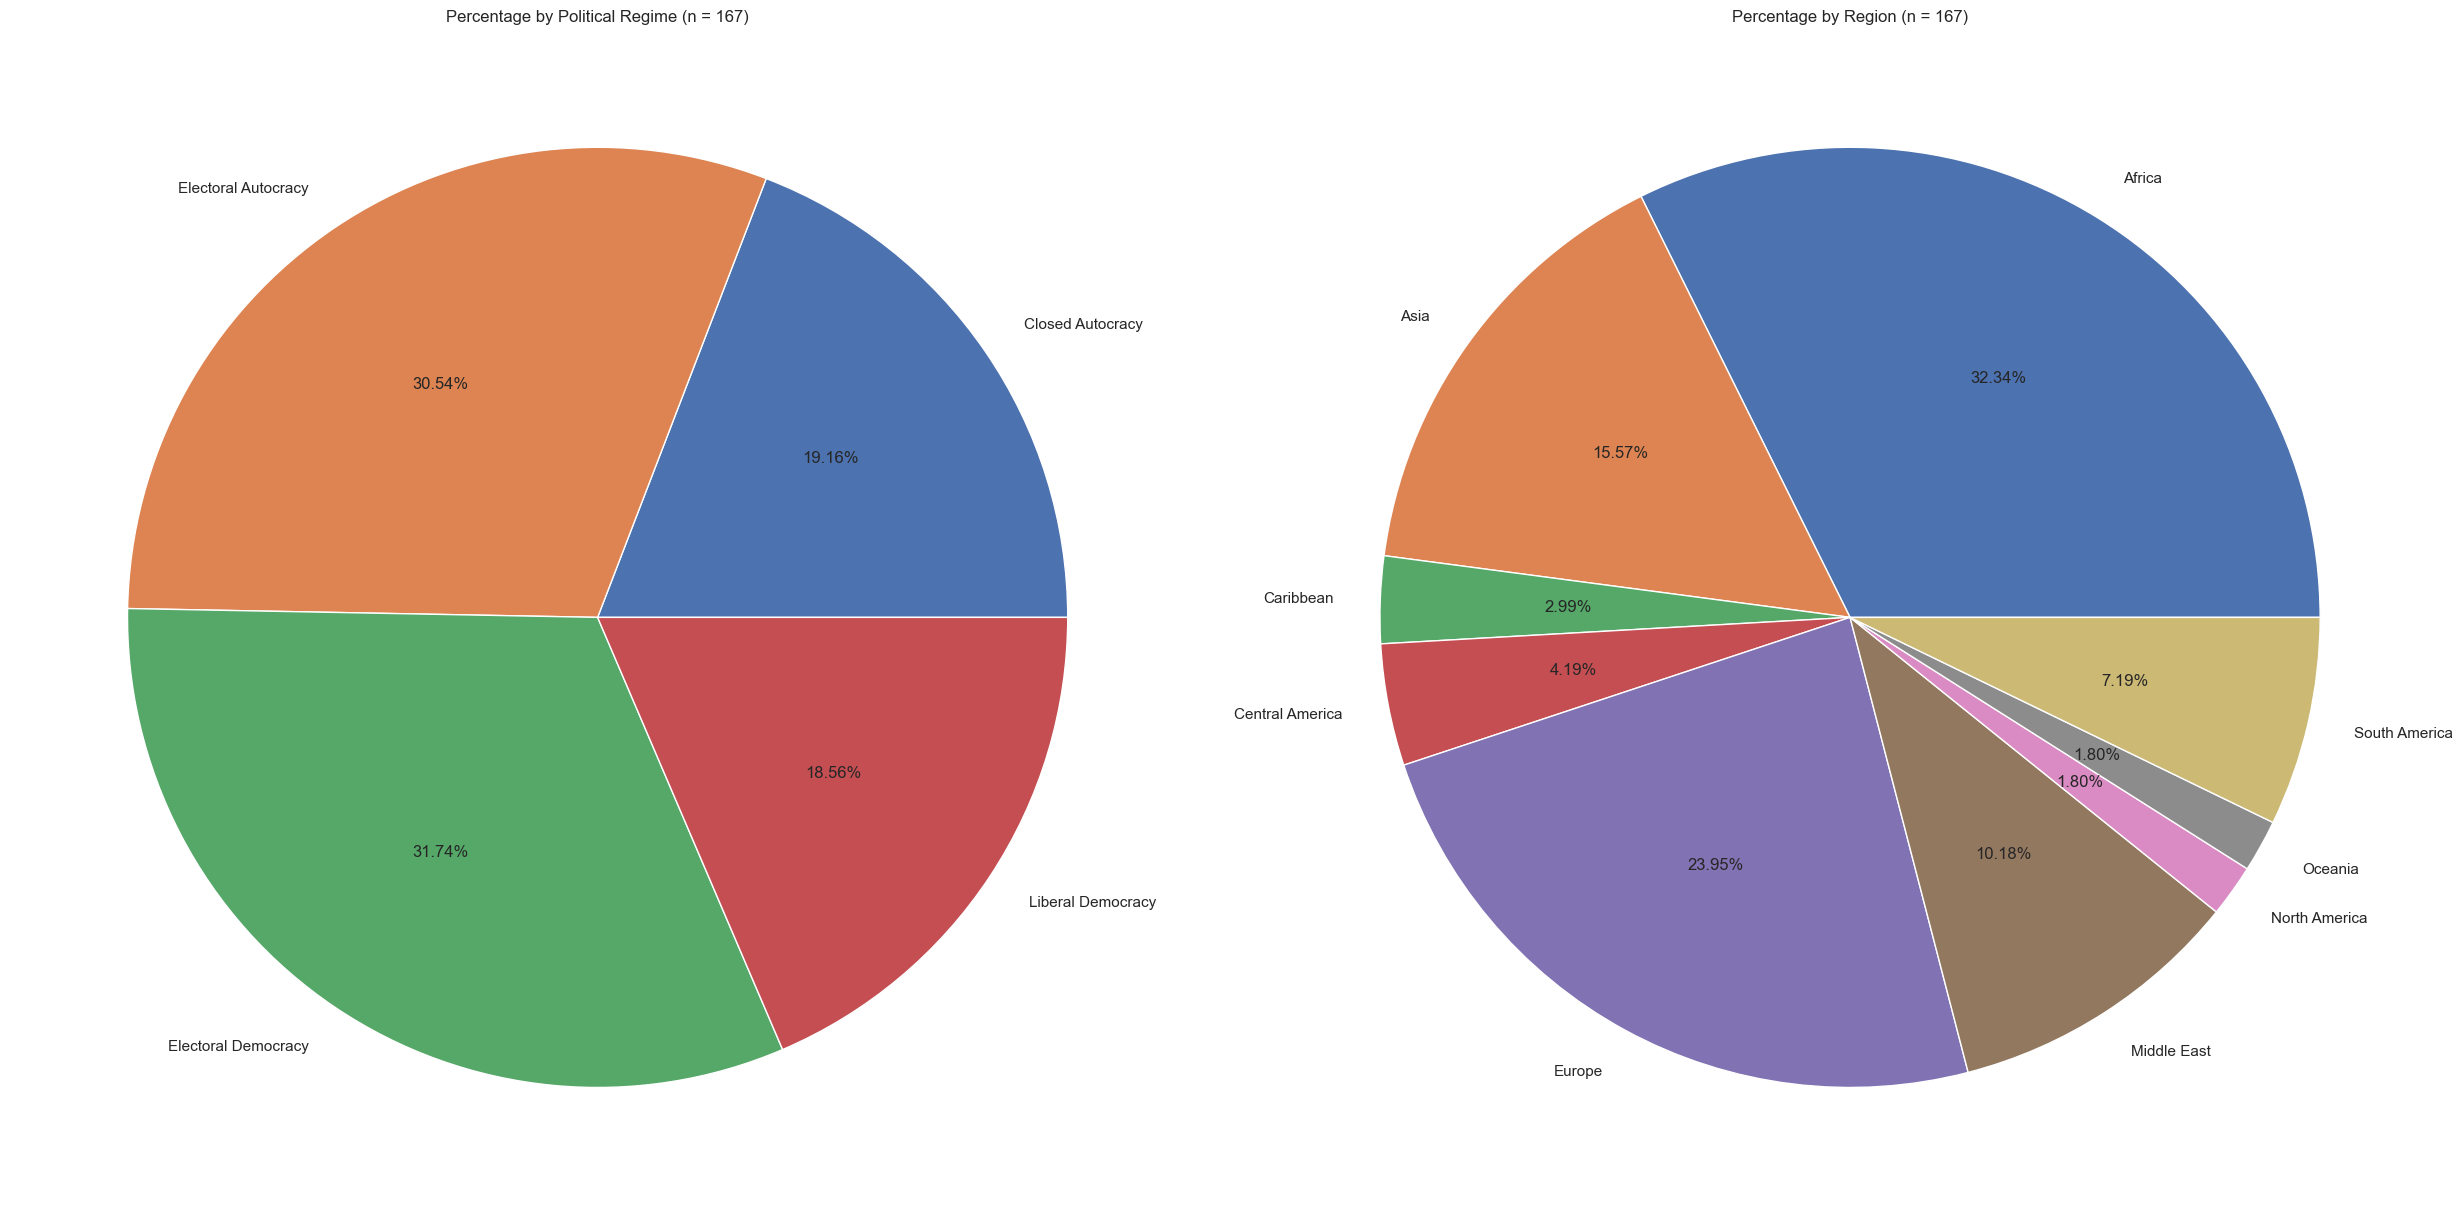

In [108]:
region_coverage = prosperity_scores.groupby("region").size()
political_regime_coverage = prosperity_scores.groupby("political_regime").size()

fig, axes = plt.subplots(1, 2, figsize=(25,20))

political_regime_coverage.plot.pie(autopct = "%.2f%%", ax = axes[0], 
                        title = "Percentage by Political Regime (n = 167)")
region_coverage.plot.pie(autopct = "%.2f%%", ax = axes[1], 
                         title = "Percentage by Region (n = 167)")

plt.tight_layout()
plt.show()

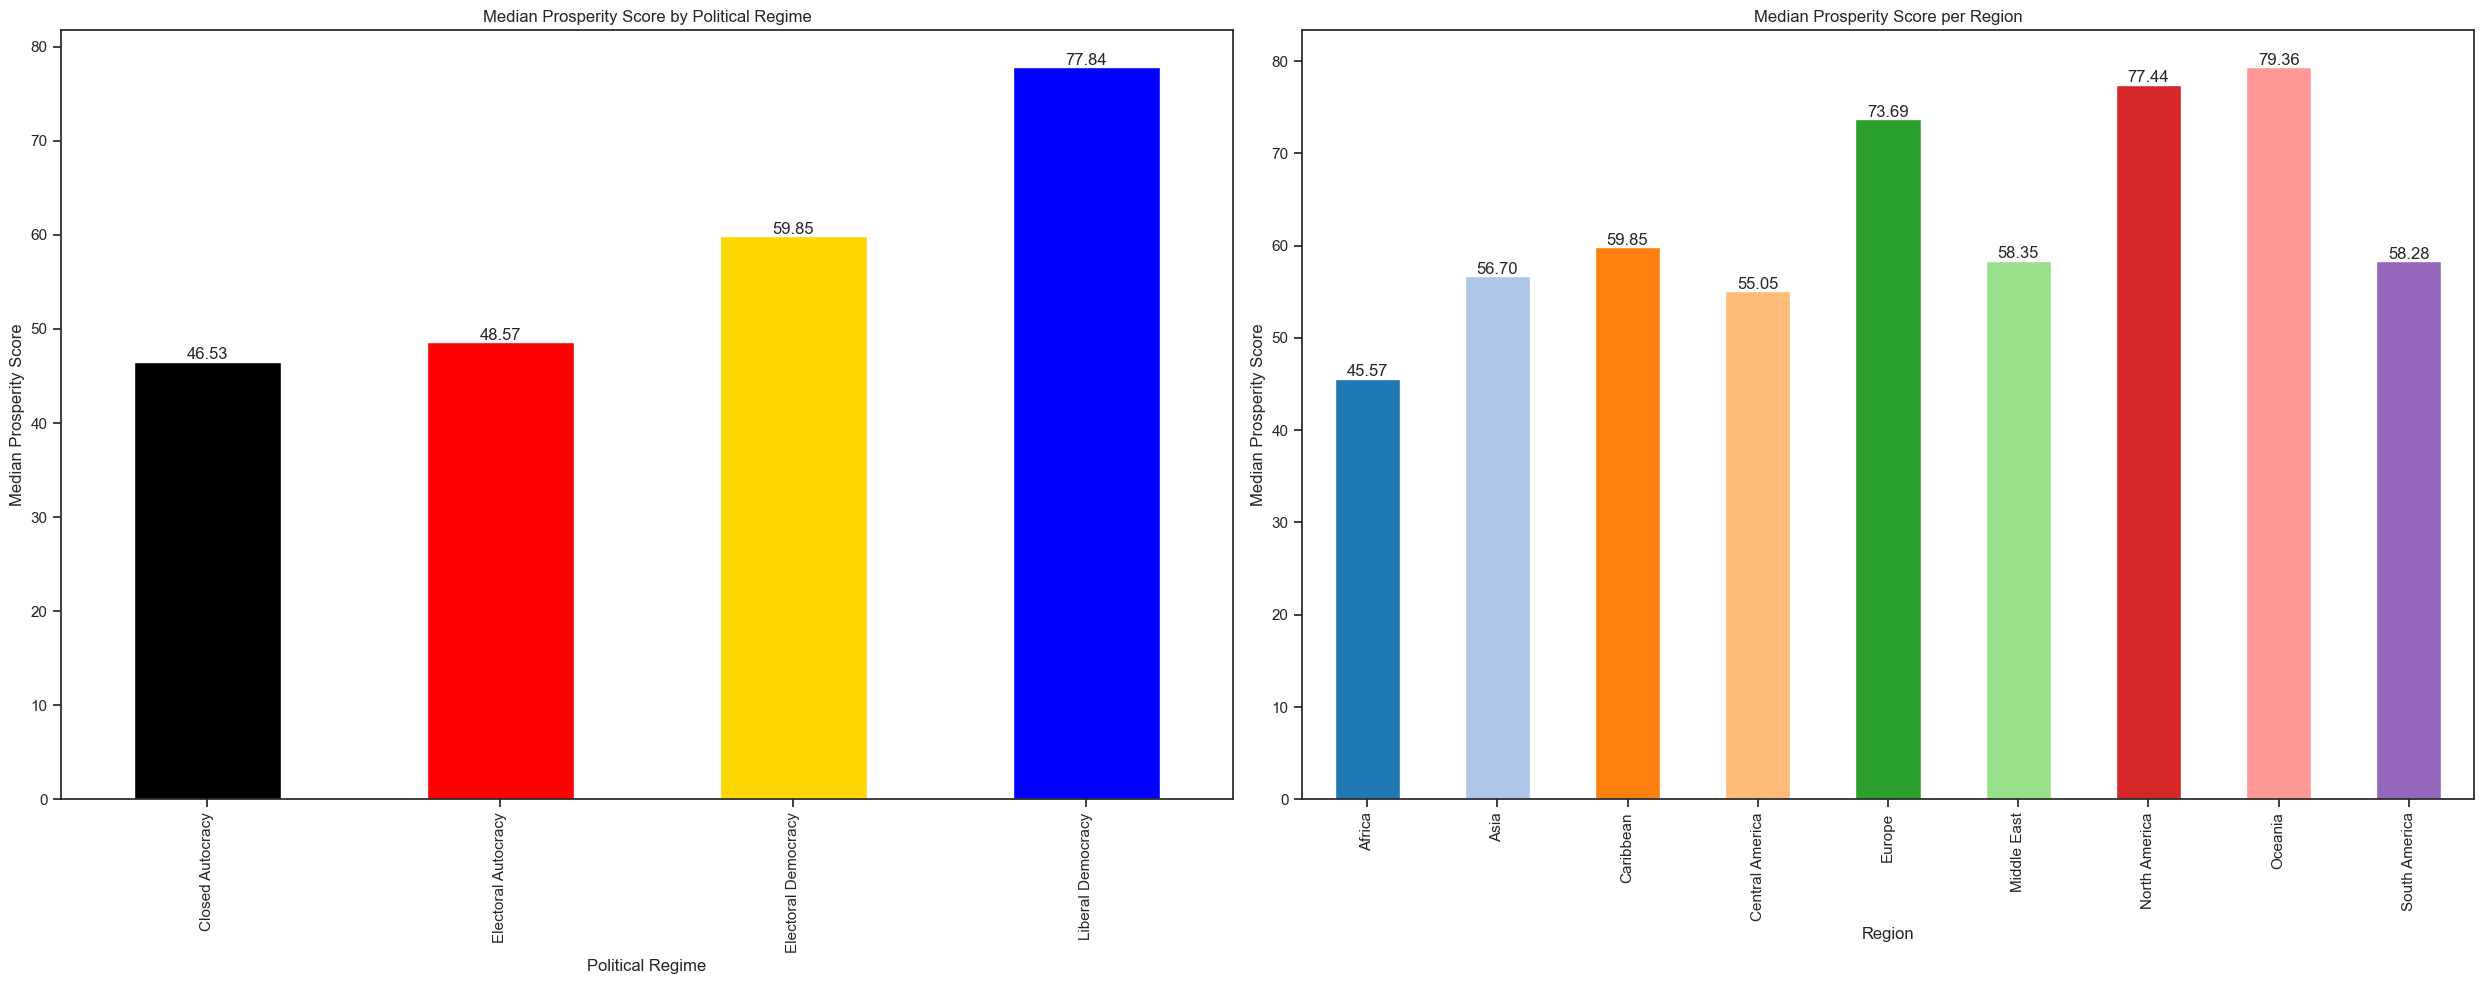

In [109]:
region_median_scores = prosperity_scores.groupby("region")["prosperity_score"].median()
regime_median_scores = prosperity_scores.groupby("political_regime")["prosperity_score"].median()

regime_colors = {
    "Liberal Democracy": (0/255, 0/255, 255/255),       # blue
    "Electoral Democracy": (255/255, 215/255, 0/255),   # yellow
    "Electoral Autocracy": (255/255, 0/255, 0/255),     # red
    "Closed Autocracy": (0/255, 0/255, 0/255)           # black
}
colors = plt.cm.tab20.colors

fig, axes = plt.subplots(1, 2, figsize = (25, 10))

ax_1 = regime_median_scores.plot(kind = "bar", 
                                 color = [regime_colors[regime] for regime in regime_median_scores.index], 
                                 ax = axes[0], grid = False, 
                                 title = "Median Prosperity Score by Political Regime")
ax_1.set_xlabel("Political Regime")
ax_1.set_ylabel("Median Prosperity Score")
for p in ax_1.patches:
    ax_1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = "center", va = "center", xytext = (0, 5), textcoords = "offset points")
    
ax_2 = region_median_scores.plot(kind = "bar", color = colors, ax = axes[1], grid = False, 
                                 title = "Median Prosperity Score per Region")
ax_2.set_xlabel("Region")
ax_2.set_ylabel("Median Prosperity Score")
for p in ax_2.patches:
    ax_2.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = "center", va = "center", xytext = (0, 5), textcoords = "offset points")
    
plt.tight_layout()
plt.show()

### Dimensionality Reduction via Principal Components Analysis (PCA) <a name="pca" /> 

The continuous variables in the dataset are all scaled out of 100, so, PCA using the covariance instead of the correlation matrix is appropriate.
We need to drop the categorical variables "region" and "political_regime" to continue due to assumptions under PCA. We removed "country" as it's the identifier.
I will not include the response variable, "prosperity_score" as I care about reducing the dimensionality of the covariates.

#### Scree Plot <a name="scree" /> 

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9
λ,0.767191,0.098511,0.038451,0.033186,0.017663,0.011638,0.008667,0.008554,0.005576


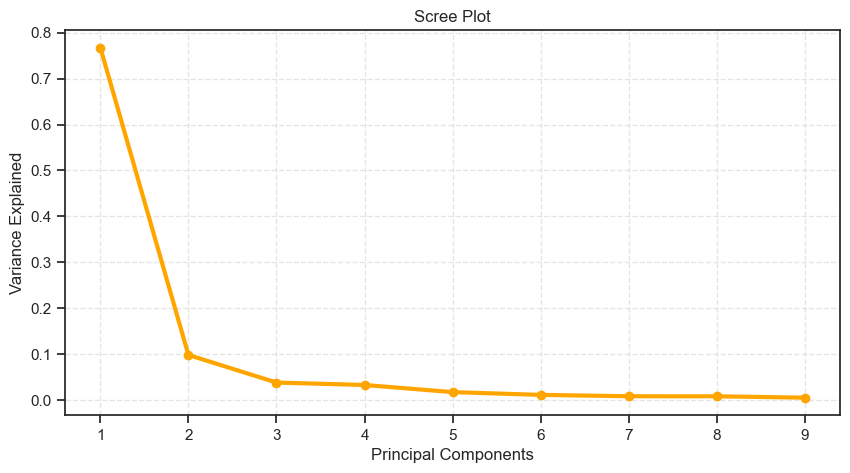

Variance explained by the first three principal components: 0.904151


In [110]:
reduced_scores_pca = prosperity_scores.drop(columns=["country", "region", "political_regime", "prosperity_score"])
pca = PCA(n_components =  9)
pca_fit = pca.fit_transform(reduced_scores_pca)
pd.set_option("display.width", 1000)
lambda_values = pd.DataFrame([pca.explained_variance_ratio_], 
                             columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5", 
                                        "PC 6", "PC 7", "PC 8", "PC 9"], 
                             index = ["λ"])
lambda_values = lambda_values.style.set_properties(**{"text-align": "right"})
display(lambda_values)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, pca.n_components_ + 1), pca.explained_variance_ratio_, 
         "o-", linewidth = 3, color = "orange")
plt.title("Scree Plot")
plt.xticks(np.arange(1, pca.n_components_ + 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()
print("Variance explained by the first three principal components:", 0.76719 + 0.09851 + 0.038451)

#### PC Loadings <a name="pc.loadings" /> 

In [111]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5",
                                   "PC 6", "PC 7", "PC 8", "PC 9"], 
                        index = reduced_scores_pca.columns)

# print(loadings.iloc[:, :3].abs().sort_values(by = "PC 1", ascending = False))

sorted_pc1 = loadings["PC 1"].abs().sort_values(ascending=False)
sorted_pc2 = loadings["PC 2"].abs().sort_values(ascending=False)
sorted_pc3 = loadings["PC 3"].abs().sort_values(ascending=False)

loadings_df = pd.DataFrame({
    "PC 1 Variables": sorted_pc1.index,
    "PC 1 Loadings": sorted_pc1.values,
    "PC 2 Variables": sorted_pc2.index,
    "PC 2 Loadings": sorted_pc2.values,
    "PC 3 Variables": sorted_pc3.index,
    "PC 3 Loadings": sorted_pc3.values
})

display(loadings_df)


,PC 1 Variables,PC 1 Loadings,PC 2 Variables,PC 2 Loadings,PC 3 Variables,PC 3 Loadings
0,education,0.377674,personal_freedom,0.687426,safety_and_security,0.477957
1,living_conditions,0.373525,living_conditions,0.383457,enterprise_conditions,0.468088
2,governance,0.341139,education,0.348467,investment_environment,0.395671
3,investment_environment,0.332258,governance,0.286297,governance,0.319125
4,personal_freedom,0.314171,health,0.239559,living_conditions,0.296612
5,infrastructure_and_market_access,0.313744,infrastructure_and_market_access,0.198092,personal_freedom,0.262571
6,safety_and_security,0.303253,natural_environment,0.195001,economic_quality,0.228359
7,economic_quality,0.253776,safety_and_security,0.145881,education,0.197617
8,enterprise_conditions,0.236961,economic_quality,0.094548,infrastructure_and_market_access,0.148488
9,health,0.198136,enterprise_conditions,0.080690,natural_environment,0.097164


#### PC Scores <a name="pc.scores" /> 

,PC1,PC2,PC3
0,92.057623,17.515008,-4.607455
1,88.520649,15.496347,-3.433577
2,89.138830,17.942185,-3.156838
3,88.665596,16.847366,-5.230212
4,89.134855,12.082003,-7.620004
...,...,...,...
162,-85.874357,8.110889,-11.422438
163,-84.325613,-1.738557,-19.242175
164,-92.287980,21.985625,-16.917134
165,-91.327499,-11.054467,-6.328751


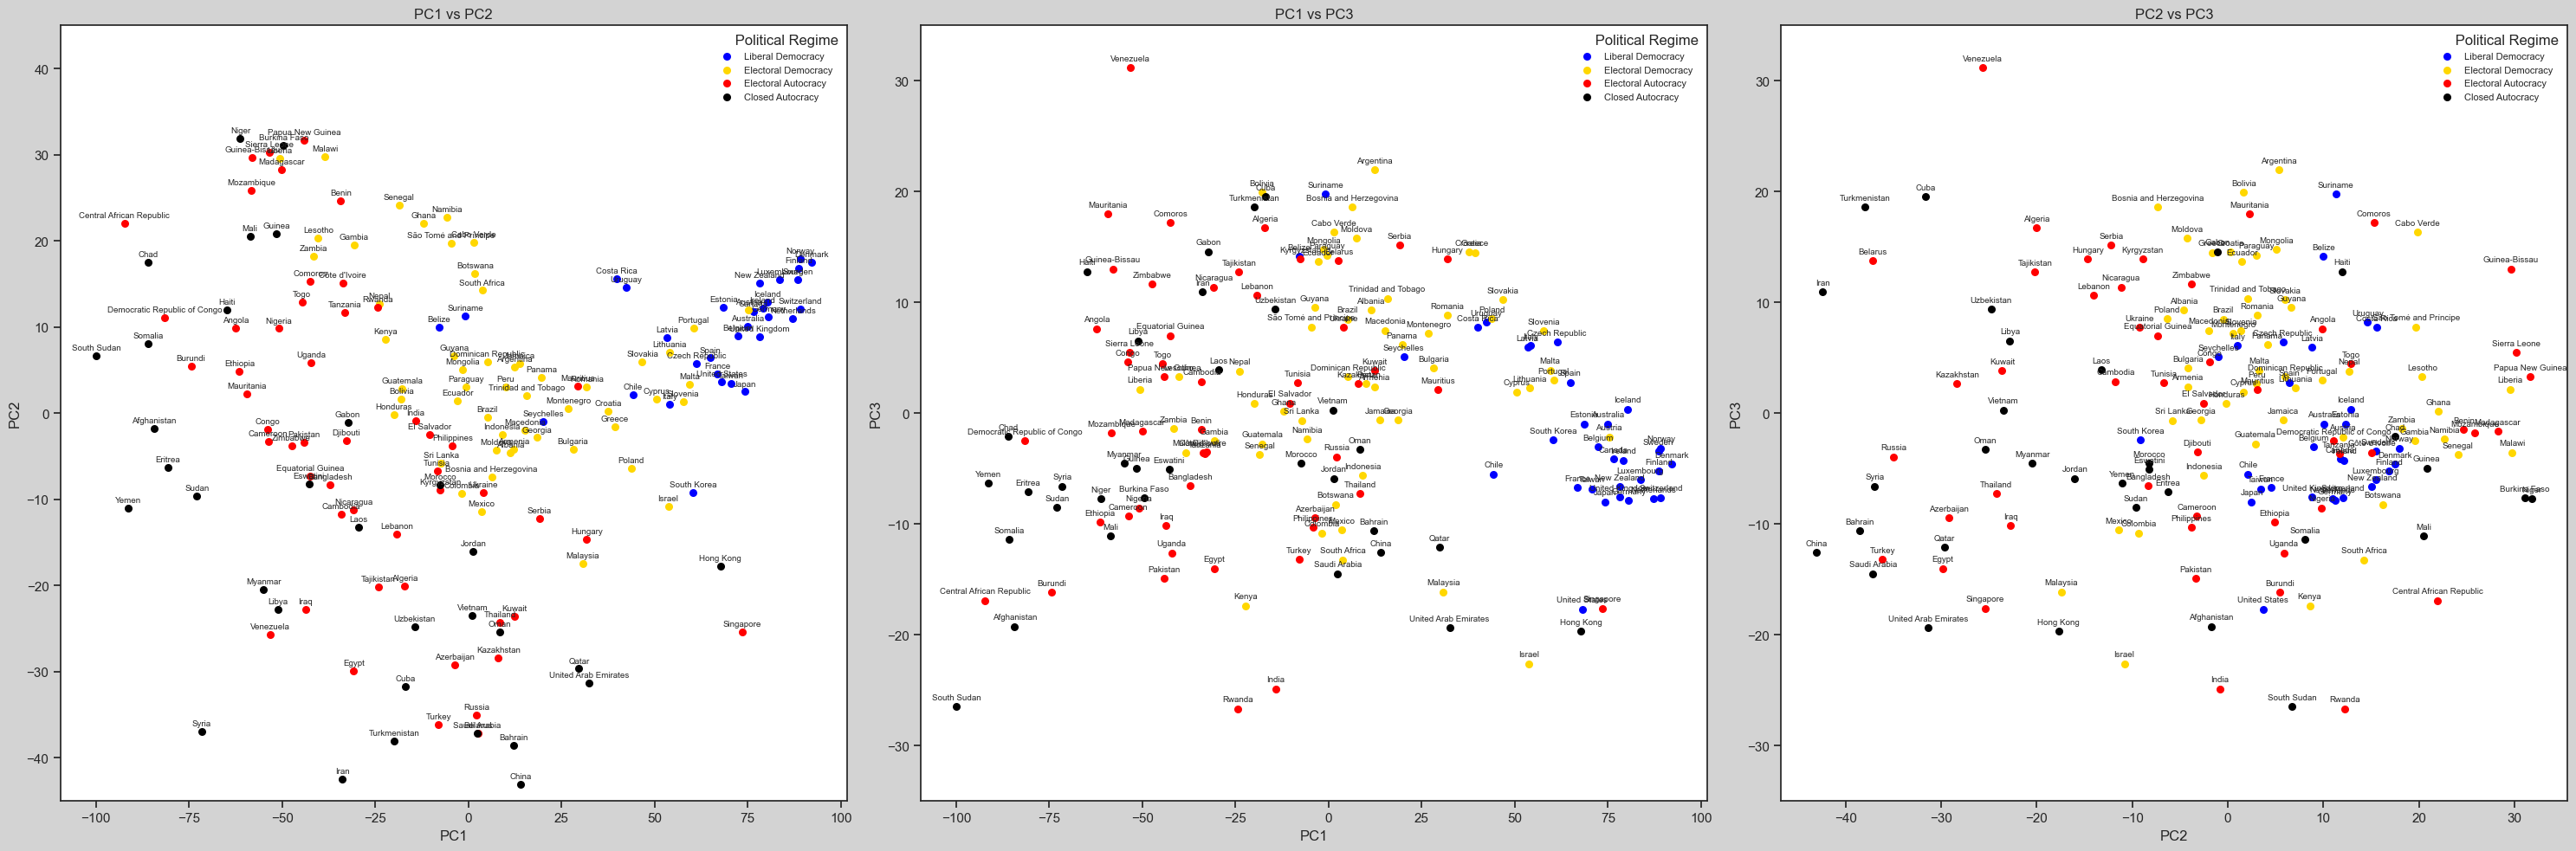

In [112]:
pc_scores = pd.DataFrame(data = pca_fit[:, :3], columns=["PC1", "PC2", "PC3"])
display(pc_scores)
pc_scores["Country"] = prosperity_scores["country"]
pc_scores["Region"] = prosperity_scores["region"]
pc_scores["Political Regime"] = prosperity_scores["political_regime"]

fig, axes = plt.subplots(1, 3, figsize = (30, 10), facecolor = "lightgray")
def plot_scatter(ax, x_col, y_col, xlabel, ylabel, title):
    
    for regime in regime_colors.keys():
        subset = pc_scores[pc_scores["Political Regime"] == regime]
        ax.scatter(subset[x_col], subset[y_col], alpha = 1, s = 30, 
                   label = regime, color = regime_colors[regime])
    for i, txt in enumerate(pc_scores["Country"]):
        ax.text(pc_scores[x_col][i], pc_scores[y_col][i] + 0.5, txt, 
                fontsize = 7, ha = "center", va = "bottom")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    legend = ax.legend(title = "      Political Regime", fontsize = 8, 
                       loc = "upper right", frameon = False)
    legend.get_frame().set_facecolor("lightgray")
    

# Plot PC1 vs PC2

plot_scatter(axes[0], "PC1", "PC2", "PC1", "PC2", "PC1 vs PC2")
axes[0].set_ylim(-45, 45)

# Plot PC1 vs PC3

plot_scatter(axes[1], "PC1", "PC3", "PC1", "PC3", "PC1 vs PC3")
axes[1].set_ylim(-35, 35)

# Plot PC2 vs PC3

plot_scatter(axes[2], "PC2", "PC3", "PC2", "PC3", "PC2 vs PC3")
axes[2].set_ylim(-35, 35)

plt.tight_layout()
plt.show()

#### Interactive 3-D Plot of PC Scores <a name="interactive.pc.scores" /> 

In [113]:
fig = px.scatter_3d(
    pc_scores, 
    x = "PC1", 
    y = "PC2", 
    z = "PC3", 
    text = "Country", 
    color = "Region",  
    opacity = 1,
    title = "Interactive 3D PCA Scatter Plot"
)

fig.update_traces(marker = dict(size = 4))
fig.update_layout(
    height = 1000, width = 1000,
    scene = dict(
        xaxis_title = "PC1",
        yaxis_title = "PC2",
        zaxis_title = "PC3"
    ),
    legend = dict(
        title = dict(text = "       Region", side = "top")
    )
)

html_filename = "pca_3d_plot_embedded.html"
pio.write_html(fig, file = html_filename, full_html = True, include_plotlyjs = "cdn")

display(HTML(f"""
    <div style="display: flex; justify-content: center;">
        <iframe src="{html_filename}" width="1100" height="1100"></iframe>
    </div>
"""))


## Homework 2 <a id="hw2"></a>

### Canonical Correlation Analysis (CCA) <a name="cca" /> 

#### Scatterplot Matrix by Political Regime <a name="scatterplot.matrix" /> 

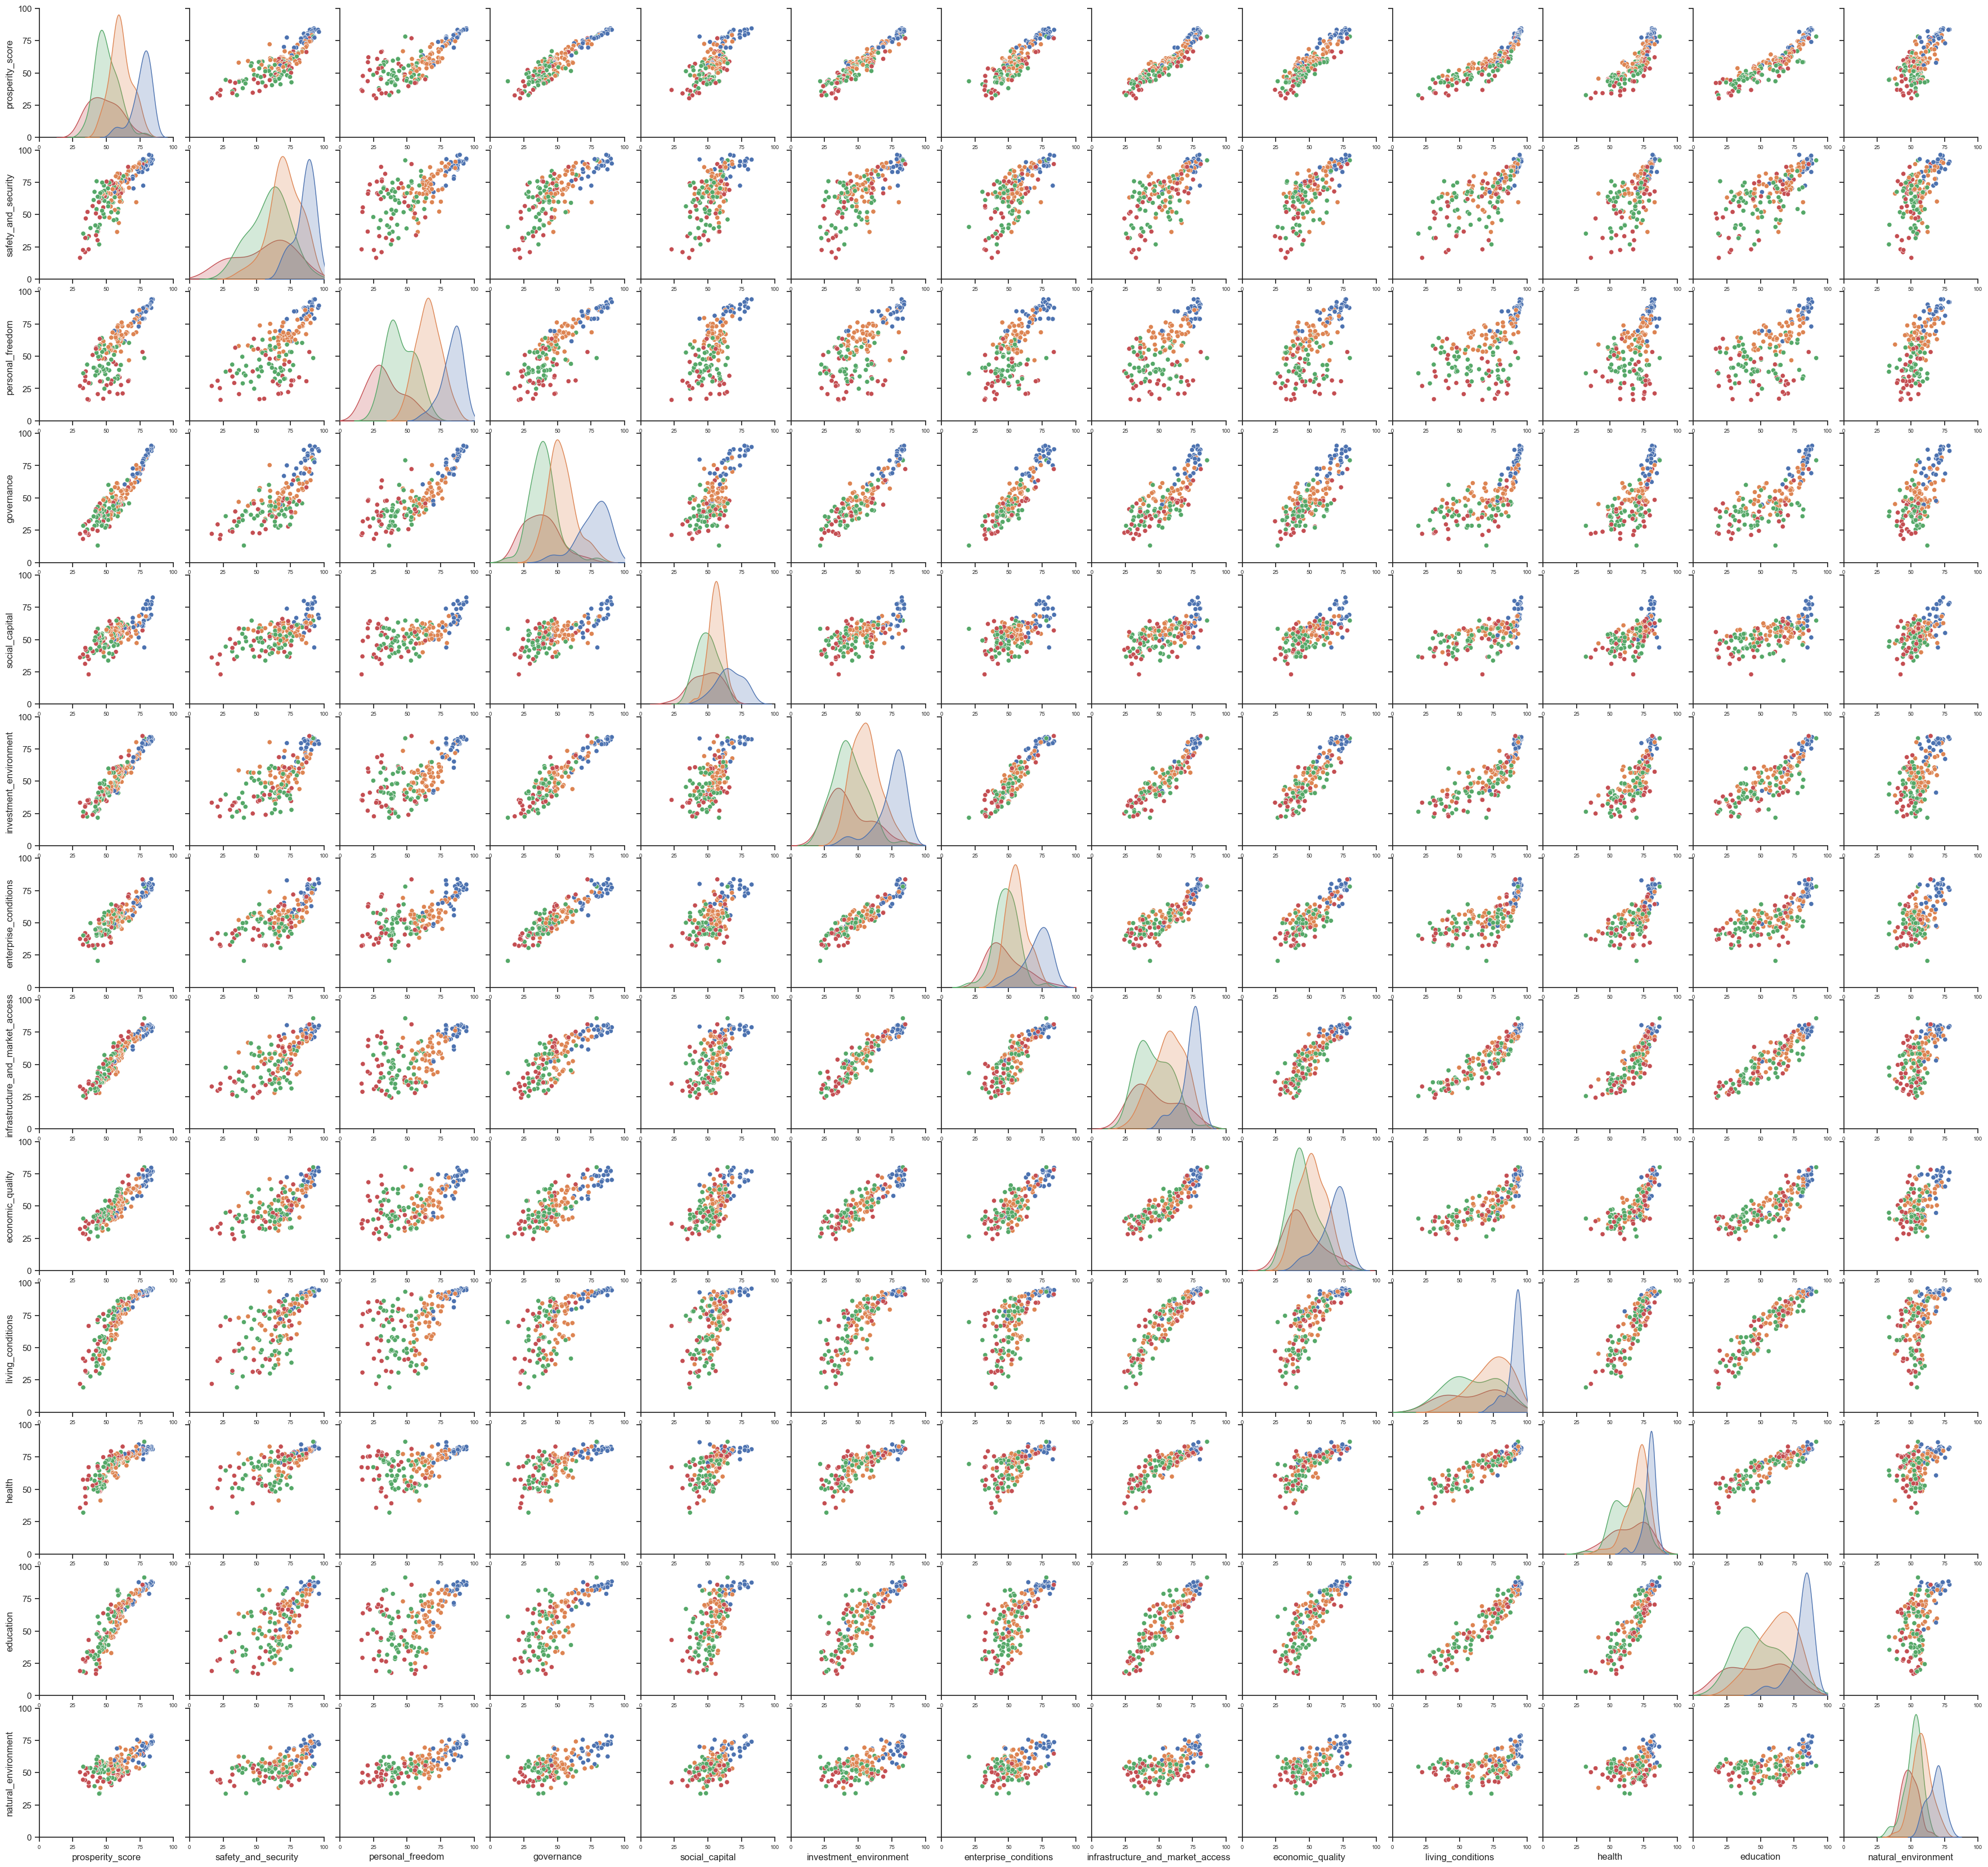

In [114]:
reduced_scores_cca1 = prosperity_scores.drop(columns = ["country", "region"])
sns.set_theme(style = "ticks")
pairplot = sns.pairplot(reduced_scores_cca1, corner = False, 
                        hue = "political_regime")
for ax in pairplot.axes.flatten():
    if ax is not None:
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.tick_params(axis='x', labelbottom=True, labelsize = 7)

if pairplot._legend:
    pairplot._legend.remove()
plt.subplots_adjust(left = 0, right = 1, top = 1, bottom = 0)
plt.show()

In [115]:
cov_matrix = np.cov(reduced_scores_cca1.iloc[:, 2:14], rowvar=False)
cov_df = pd.DataFrame(cov_matrix, 
                      index=reduced_scores_cca1.columns[2:14], 
                      columns=reduced_scores_cca1.columns[2:14])

print("Covariance Matrix\n")
print(cov_df.round(4)) 


Covariance Matrix

                                  safety_and_security  personal_freedom  governance  social_capital  investment_environment  enterprise_conditions  infrastructure_and_market_access  economic_quality  living_conditions    health  education  natural_environment
safety_and_security                          307.7315          228.8295    237.4015        110.3507                213.8208               156.0848                          197.7355          167.1971           241.1957  125.7412   243.7550              91.8700
personal_freedom                             228.8295          396.5928    288.5067        128.8678                223.4230               166.5878                          185.2536          152.3546           212.6636   99.9767   213.8601             130.3783
governance                                   237.4015          288.5067    314.9593        127.9262                269.7671               208.5926                          229.0567          195.3024   

#### CCA with each Domain of Prosperity <a name="cca.plots" /> 

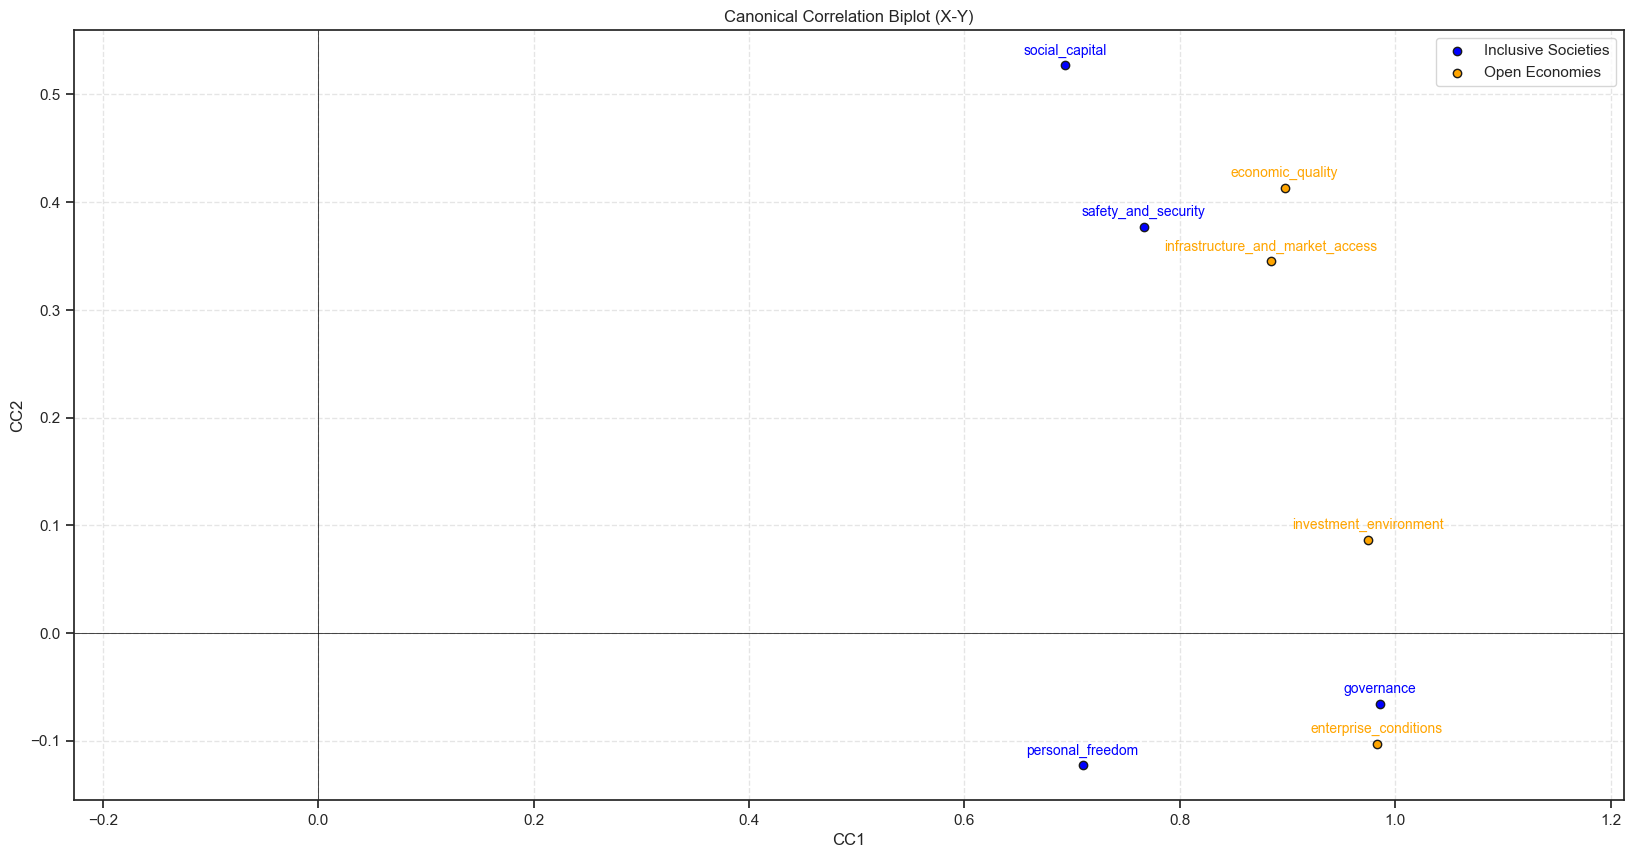

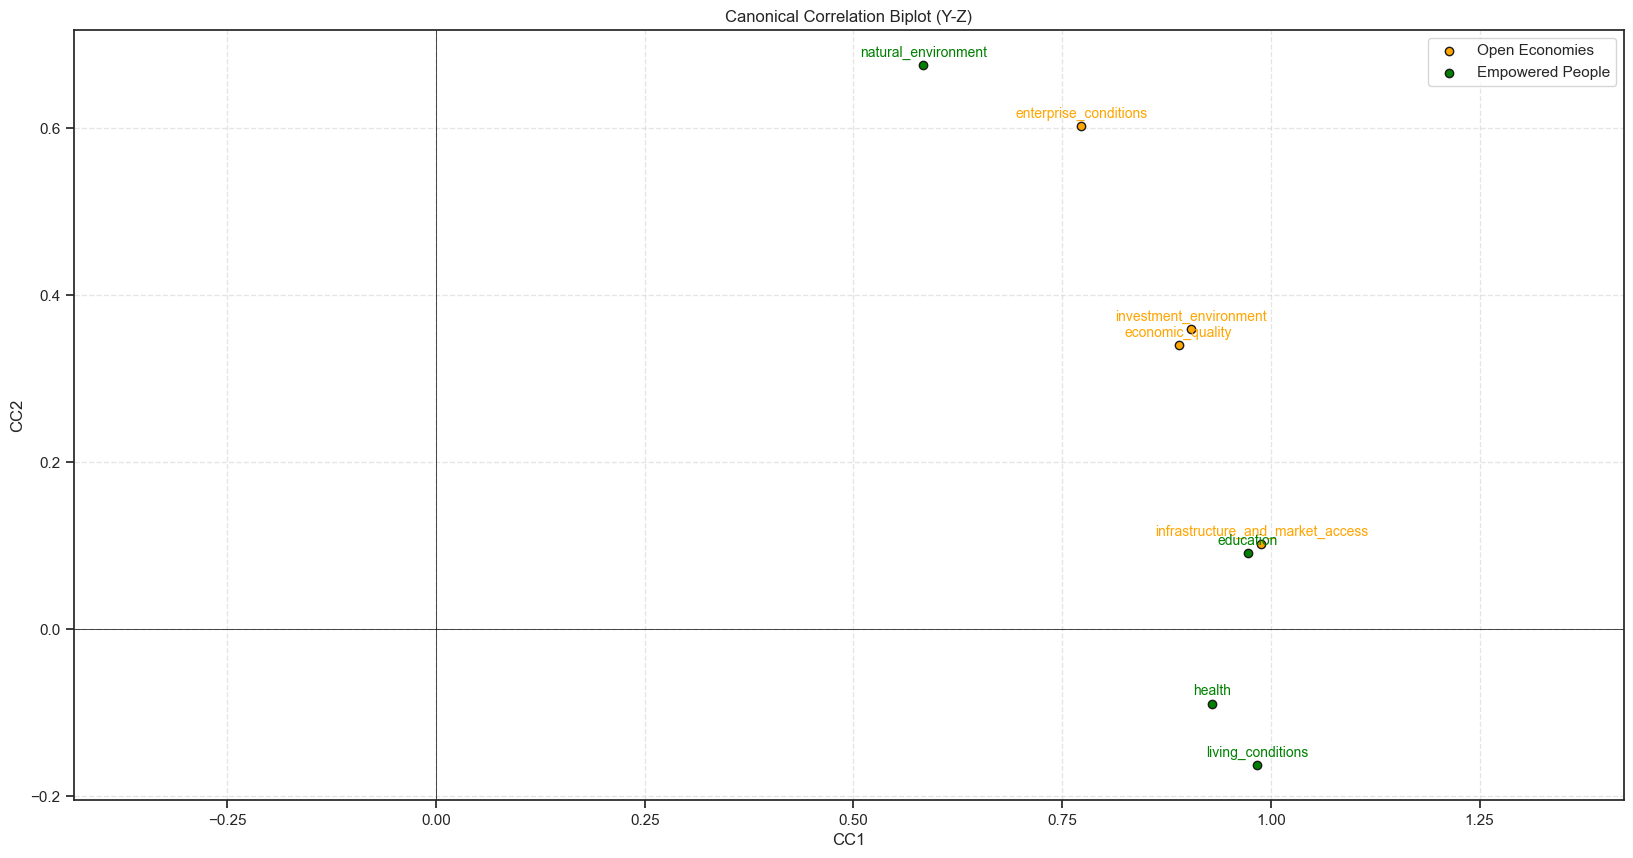

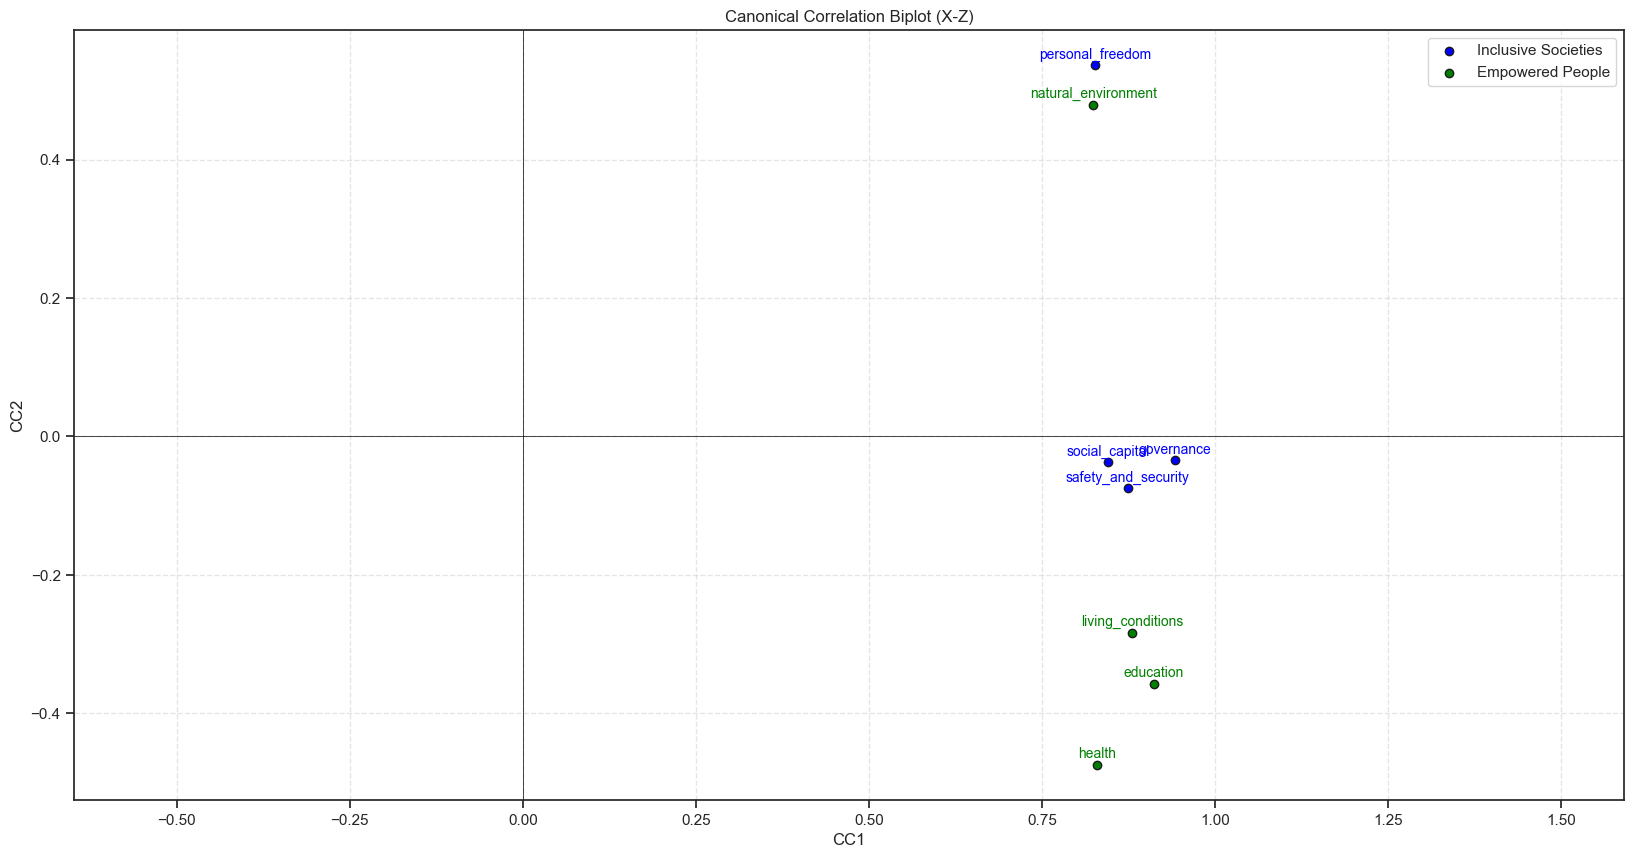

,Variables (X-Y),CC1 (X-Y),CC2 (X-Y),Variables (Y-Z),CC1 (Y-Z),CC2 (Y-Z),Variables (X-Z),CC1 (X-Z),CC2 (X-Z)
0,safety_and_security,0.766259,0.377217,investment_environment,0.904702,0.359202,safety_and_security,0.873955,-0.074875
1,personal_freedom,0.709717,-0.122756,enterprise_conditions,0.773049,0.602481,personal_freedom,0.827327,0.536472
2,governance,0.985389,-0.065658,infrastructure_and_market_access,0.988758,0.102599,governance,0.942185,-0.034685
3,social_capital,0.693522,0.527089,economic_quality,0.889644,0.341073,social_capital,0.845719,-0.037266
4,investment_environment,0.974755,0.086395,living_conditions,0.983572,-0.162771,living_conditions,0.880520,-0.283617
5,enterprise_conditions,0.983017,-0.102663,health,0.930026,-0.089024,health,0.829200,-0.475075
6,infrastructure_and_market_access,0.884442,0.345321,education,0.972103,0.091340,education,0.911544,-0.357225
7,economic_quality,0.897310,0.413459,natural_environment,0.583482,0.675704,natural_environment,0.824446,0.479490


In [ ]:
reduced_scores_cca2 = prosperity_scores.drop(columns=["country", "region", "political_regime", "prosperity_score"])

# Separate the 12 prosperity variables into their respective groups as numpy arrays

x = reduced_scores_cca2.iloc[:, np.r_[0:4]].to_numpy()  # Inclusive Societies (blue)
y = reduced_scores_cca2.iloc[:, np.r_[4:8]].to_numpy()  # Open Economies (orange)
z = reduced_scores_cca2.iloc[:, np.r_[8:12]].to_numpy() # Empowered People (green)

# CCA from sci-kit learn

cca_xy = CCA(n_components=2)
cca_yz = CCA(n_components=2)
cca_xz = CCA(n_components=2)

cca_xy.fit(x, y)
cca_yz.fit(y, z)
cca_xz.fit(x, z)

# Compute canonical scores

x_c_xy, y_c_xy = cca_xy.transform(x, y)
y_c_yz, z_c_yz = cca_yz.transform(y, z)
x_c_xz, z_c_xz = cca_xz.transform(x, z)

# Compute canonical correlations

cor_x_xy = np.array([np.corrcoef(x[:, i], x_c_xy[:, 0])[0, 1] for i in range(x.shape[1])])
cor_y_xy = np.array([np.corrcoef(y[:, i], y_c_xy[:, 0])[0, 1] for i in range(y.shape[1])])
cor_y_yz = np.array([np.corrcoef(y[:, i], y_c_yz[:, 0])[0, 1] for i in range(y.shape[1])])
cor_z_yz = np.array([np.corrcoef(z[:, i], z_c_yz[:, 0])[0, 1] for i in range(z.shape[1])])
cor_x_xz = np.array([np.corrcoef(x[:, i], x_c_xz[:, 0])[0, 1] for i in range(x.shape[1])])
cor_z_xz = np.array([np.corrcoef(z[:, i], z_c_xz[:, 0])[0, 1] for i in range(z.shape[1])])

# Stack correlations for CC1 and CC2

cor_x_xy = np.column_stack((cor_x_xy, [np.corrcoef(x[:, i], x_c_xy[:, 1])[0, 1] for i in range(x.shape[1])]))
cor_y_xy = np.column_stack((cor_y_xy, [np.corrcoef(y[:, i], y_c_xy[:, 1])[0, 1] for i in range(y.shape[1])]))
cor_y_yz = np.column_stack((cor_y_yz, [np.corrcoef(y[:, i], y_c_yz[:, 1])[0, 1] for i in range(y.shape[1])]))
cor_z_yz = np.column_stack((cor_z_yz, [np.corrcoef(z[:, i], z_c_yz[:, 1])[0, 1] for i in range(z.shape[1])]))
cor_x_xz = np.column_stack((cor_x_xz, [np.corrcoef(x[:, i], x_c_xz[:, 1])[0, 1] for i in range(x.shape[1])]))
cor_z_xz = np.column_stack((cor_z_xz, [np.corrcoef(z[:, i], z_c_xz[:, 1])[0, 1] for i in range(z.shape[1])]))

# Retrieve variable names

x_labels = reduced_scores_cca2.columns[:4].tolist()
y_labels = reduced_scores_cca2.columns[4:8].tolist()
z_labels = reduced_scores_cca2.columns[8:12].tolist()

def plot_biplot(cor_x, cor_y, x_labels, y_labels, color_x, color_y, label_x, label_y, title):
    plt.figure(figsize=(20, 10))

    plt.scatter(cor_x[:, 0], cor_x[:, 1], color=color_x, label=label_x, edgecolors="k")
    plt.scatter(cor_y[:, 0], cor_y[:, 1], color=color_y, label=label_y, edgecolors="k")

    for i, label in enumerate(x_labels):
        plt.text(cor_x[i, 0], cor_x[i, 1] + 0.01, label, color=color_x, fontsize = 10, ha='center')
    
    for i, label in enumerate(y_labels):
        plt.text(cor_y[i, 0], cor_y[i, 1] + 0.01, label, color=color_y, fontsize = 10, ha='center')

    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.xlabel("CC1")
    plt.ylabel("CC2")
    plt.title(title)
    plt.axis("equal")
    plt.legend(loc="upper right", bbox_to_anchor=(1, 1), frameon = True)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# X-Y Biplot (Inclusive Societies vs Open Economies)

plot_biplot(cor_x_xy, cor_y_xy, x_labels, y_labels, "blue", "orange", 
            "Inclusive Societies", "Open Economies", 
            "Canonical Correlation Biplot (X-Y)")

# Y-Z Biplot (Open Economies vs Empowered People)

plot_biplot(cor_y_yz, cor_z_yz, y_labels, z_labels, "orange", "green", 
            "Open Economies", "Empowered People", 
            "Canonical Correlation Biplot (Y-Z)")

# X-Z Biplot (Inclusive Societies vs Empowered People)

plot_biplot(cor_x_xz, cor_z_xz, x_labels, z_labels, "blue", "green", 
            "Inclusive Societies", "Empowered People", 
            "Canonical Correlation Biplot (X-Z)")

verification_df = pd.DataFrame({
    "Variables (X-Y)": x_labels + y_labels,
    "CC1 (X-Y)": list(cor_x_xy[:, 0]) + list(cor_y_xy[:, 0]),
    "CC2 (X-Y)": list(cor_x_xy[:, 1]) + list(cor_y_xy[:, 1]),
    "Variables (Y-Z)": y_labels + z_labels,
    "CC1 (Y-Z)": list(cor_y_yz[:, 0]) + list(cor_z_yz[:, 0]),
    "CC2 (Y-Z)": list(cor_y_yz[:, 1]) + list(cor_z_yz[:, 1]),
    "Variables (X-Z)": x_labels + z_labels,
    "CC1 (X-Z)": list(cor_x_xz[:, 0]) + list(cor_z_xz[:, 0]),
    "CC2 (X-Z)": list(cor_x_xz[:, 1]) + list(cor_z_xz[:, 1])
})

from IPython.display import display
display(verification_df)

### Assessing Normality <a name="normality" /> 

#### Histograms of Variables <a name="histograms" /> 

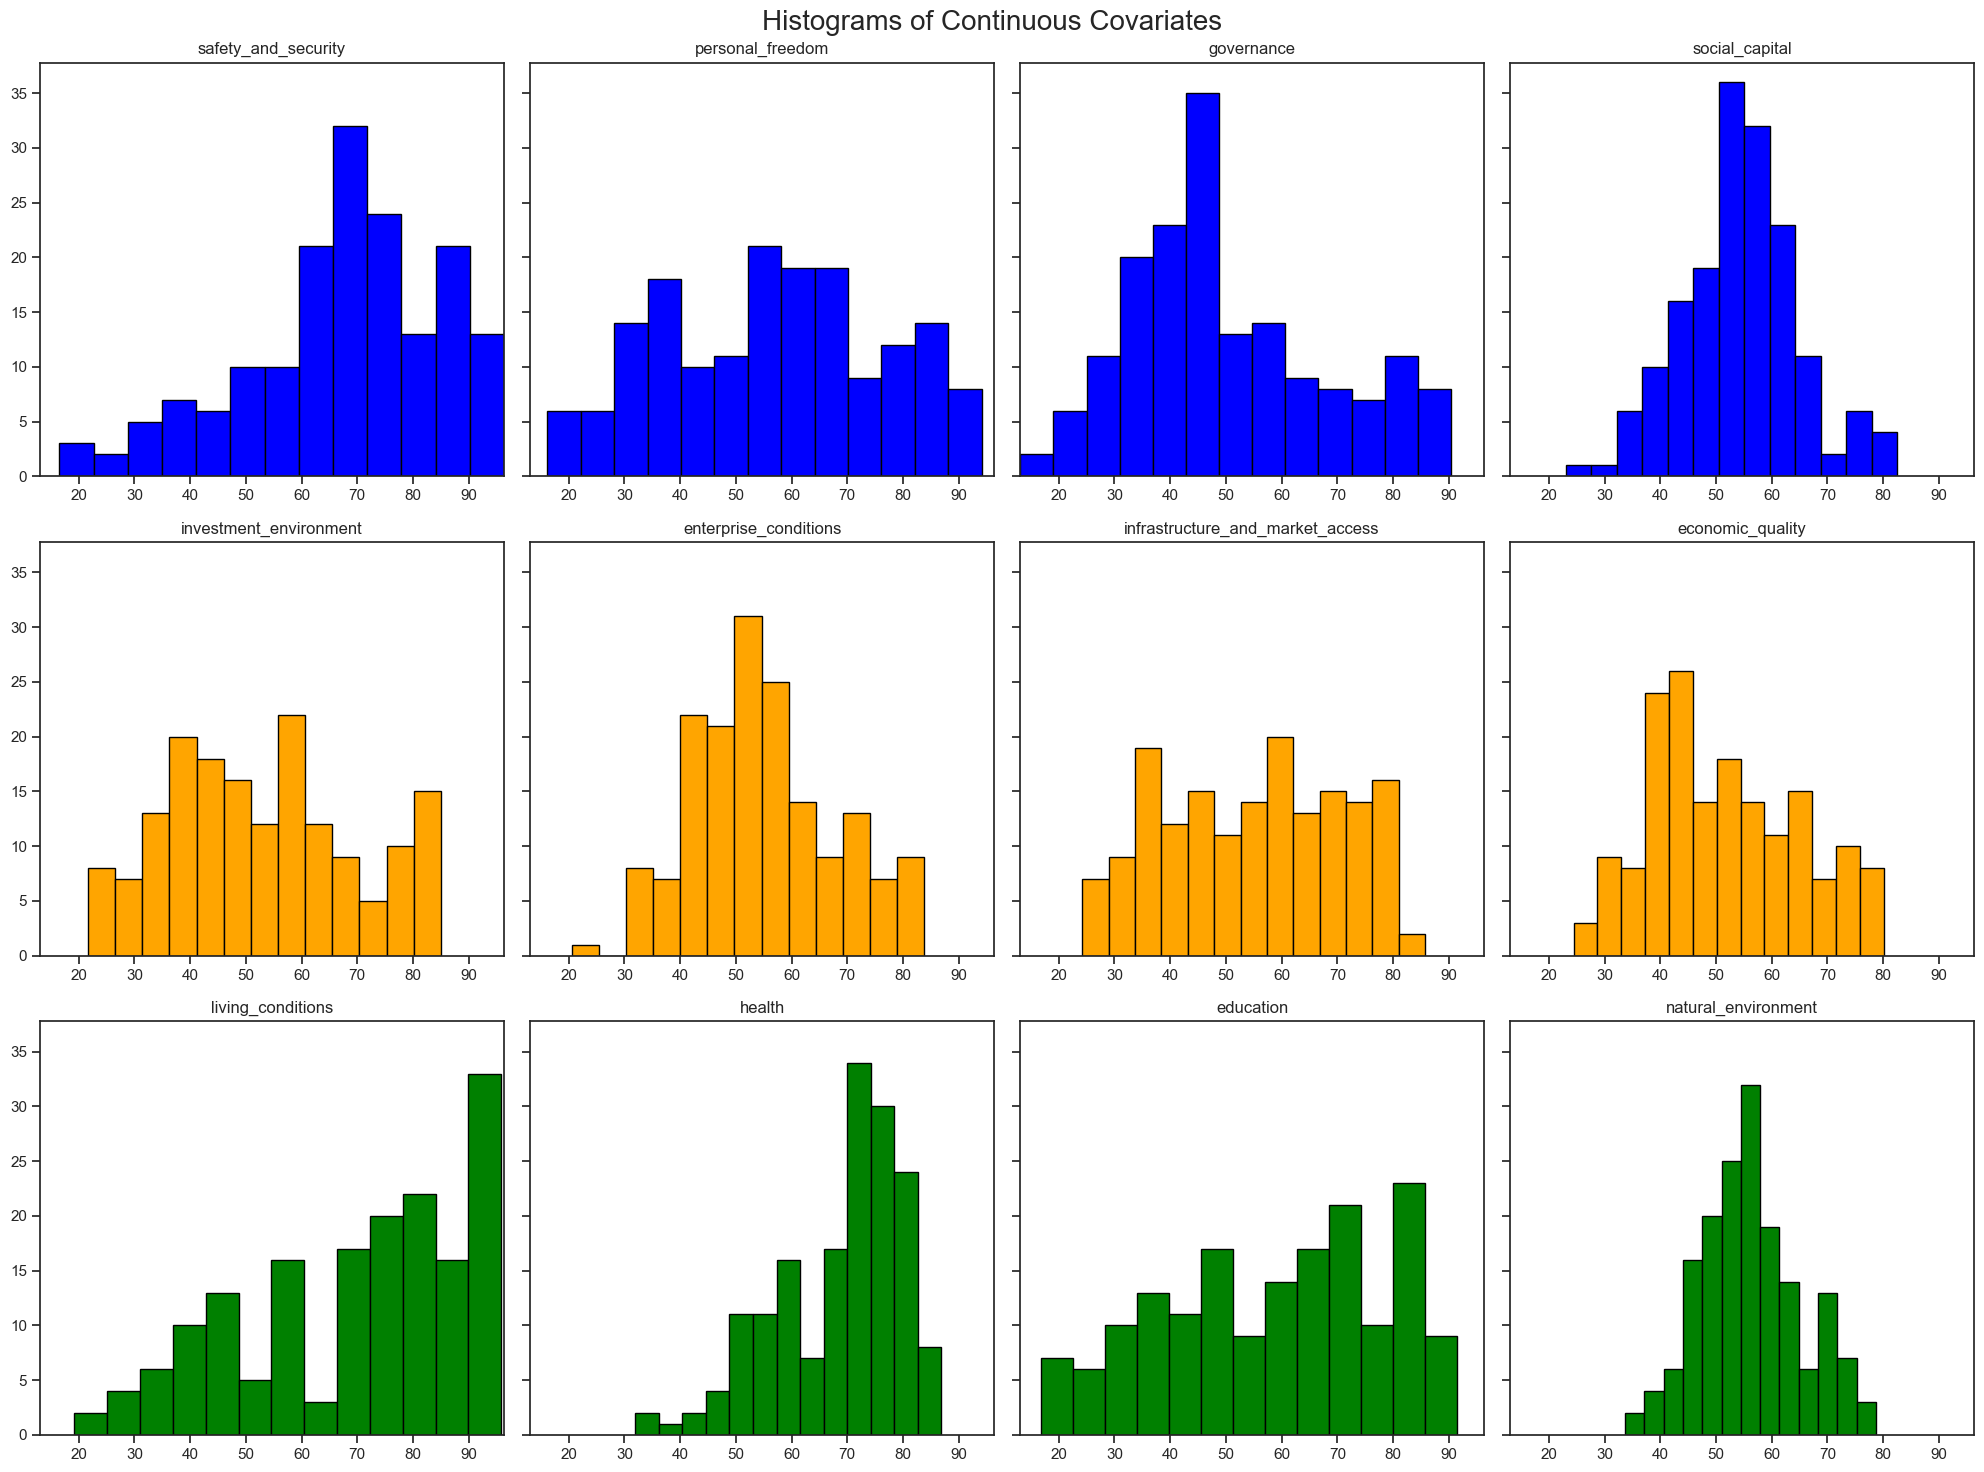

In [117]:
import numpy as np
import matplotlib.pyplot as plt

columns_to_plot = reduced_scores_cca1.iloc[:, 2:14]
rows, cols = 3, 4  
fig, axes = plt.subplots(rows, cols, figsize=(20, 15), sharex=True, sharey=True) 
axes = axes.flatten()
row_colors = np.array(['blue', 'orange', 'green'])
colors = np.repeat(row_colors, cols) 
x_min, x_max = columns_to_plot.min().min(), columns_to_plot.max().max()

for ax, col, color in zip(axes, columns_to_plot.columns, colors):
    ax.hist(columns_to_plot[col], bins=13, edgecolor='black', color=color)
    ax.set_title(col)
    ax.set_xlim([x_min, x_max])
    ax.tick_params(axis='x', labelbottom=True)

fig.suptitle('Histograms of Continuous Covariates', fontsize=20)
plt.tight_layout()
plt.show()


#### Normal Quantile-Quantile Plots <a name="qqplots" /> 

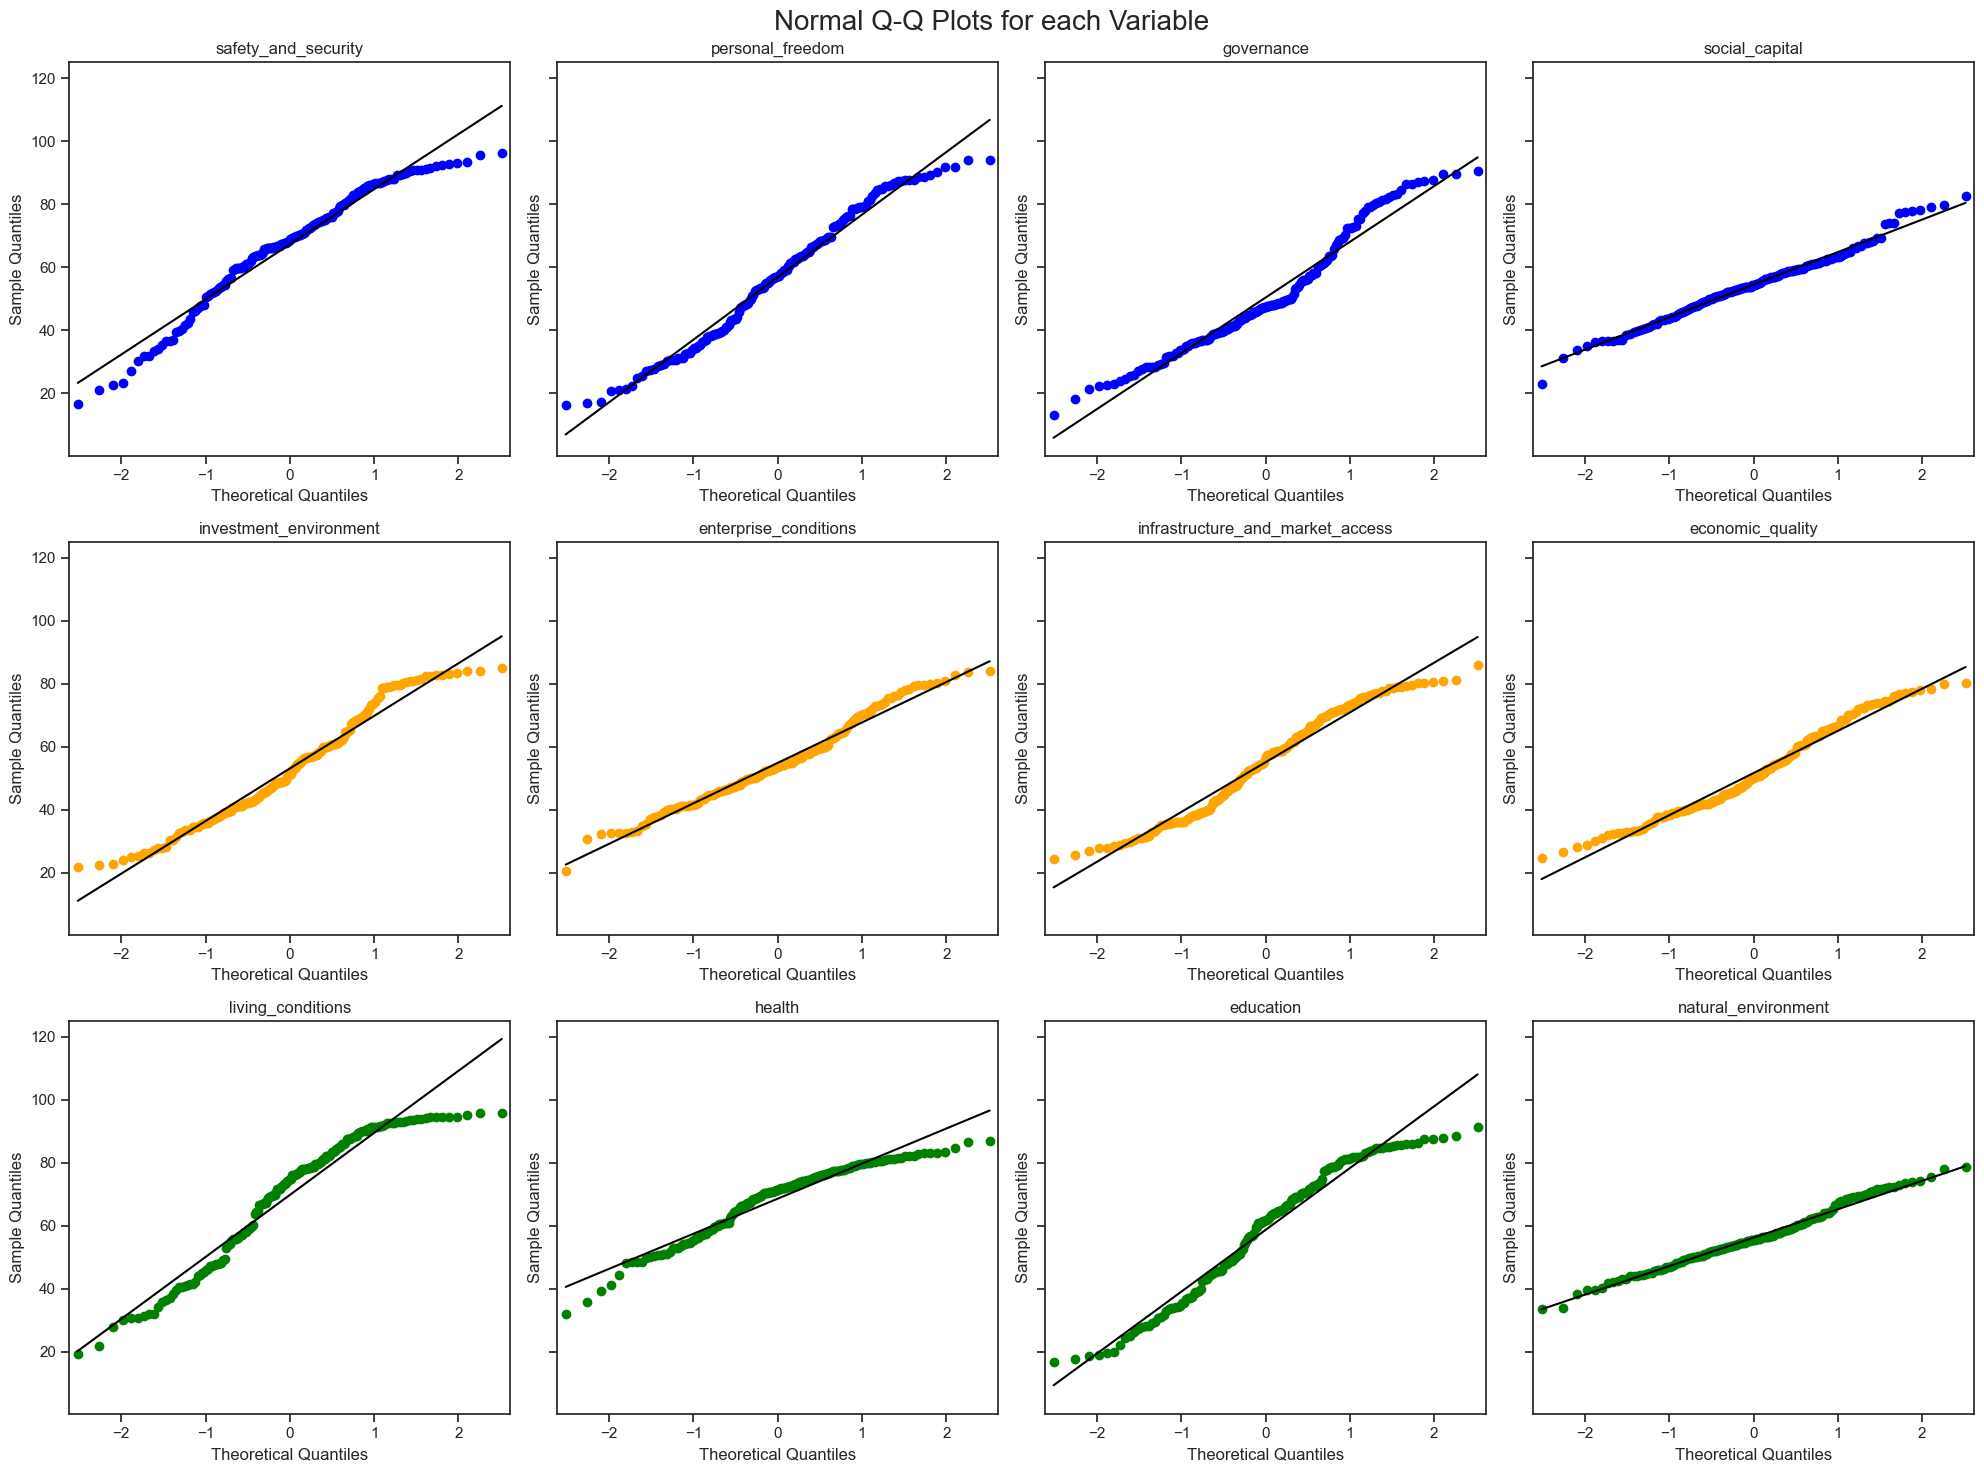

In [118]:
qq_data = reduced_scores_cca1.iloc[:, 2:14]

rows, cols = 3, 4  
fig, axes = plt.subplots(rows, cols, figsize=(20, 15), sharex=True, sharey=True)

axes = axes.flatten()

colors = ['blue'] * 4 + ['orange'] * 4 + ['green'] * 4

for ax, col, color in zip(axes, qq_data.columns, colors):
    qqplot = sm.qqplot(qq_data[col], line='s', ax=ax)
    ax.set_title(f"{col}", fontsize=12)
    
    lines = ax.get_lines()
    lines[1].set_color('black')  
    lines[0].set_color(color)   
    lines[0].set_markerfacecolor(color)  
    lines[0].set_markeredgecolor(color)  

    ax.tick_params(axis='x', labelbottom=True)

fig.suptitle("Normal Q-Q Plots for each Variable", fontsize=20)
plt.tight_layout()
plt.show()

### K-Nearest Neighbors <a name="knn" /> 

In [119]:
predictors = reduced_scores_cca1.iloc[:, 2:14]
target = prosperity_scores["political_regime"]

x_train, x_test, y_train, y_test = train_test_split(predictors, target, test_size = 0.3, random_state = 0)

model_knn = KNeighborsClassifier(n_neighbors=13)
model_knn.fit(x_train, y_train)

y_pred = model_knn.predict(x_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

                     precision    recall  f1-score   support

   Closed Autocracy       0.83      0.50      0.62        10
Electoral Autocracy       0.65      0.72      0.68        18
Electoral Democracy       0.75      0.75      0.75        16
  Liberal Democracy       0.67      0.86      0.75         7

           accuracy                           0.71        51
          macro avg       0.72      0.71      0.70        51
       weighted avg       0.72      0.71      0.70        51



### LASSO <a name="lasso" /> 

In [120]:
predictors = reduced_scores_cca1.iloc[:, 2:14]
target = prosperity_scores["prosperity_score"]

x_train, x_test, y_train, y_test = train_test_split(predictors, target, test_size = 0.3, random_state = 0)

model = LassoCV(cv = 10, random_state = 0, max_iter = 1000000)
model.fit(x_train, y_train)
print(model.alpha_) # 0.24337015324019023

model_lasso = Lasso(alpha = model.alpha_)
model_lasso.fit(x_train, y_train)
print("\nLASSO Coefficients\n")
lasso_df = pd.DataFrame(model_lasso.coef_, index = predictors.columns, columns = ["Coefficient"])
print(lasso_df)

print('\nR^2: Training Set', round(model_lasso.score(x_train, y_train)*100, 2))
print('R^2: Test Set', round(model_lasso.score(x_test, y_test)*100, 2))

y_mean = y_train.mean()
y_baseline_pred = [y_mean] * len(y_test)
base_mse = mean_squared_error(y_test, y_baseline_pred)
print("Baseline MSE (Mean Predictor):", base_mse)
lasso_mse = mean_squared_error(y_test, model_lasso.predict(x_test))
print("LASSO MSE:", lasso_mse)
print("Improvement over Baseline:", round((base_mse - lasso_mse) / base_mse * 100, 2), "%")


0.24337015324019023

LASSO Coefficients

                                  Coefficient
safety_and_security                  0.083155
personal_freedom                     0.083011
governance                           0.087031
social_capital                       0.081480
investment_environment               0.085741
enterprise_conditions                0.076556
infrastructure_and_market_access     0.085960
economic_quality                     0.082212
living_conditions                    0.084339
health                               0.078228
education                            0.083892
natural_environment                  0.079988

R^2: Training Set 100.0
R^2: Test Set 100.0
Baseline MSE (Mean Predictor): 160.72923036345034
LASSO MSE: 0.0022427646334566204
Improvement over Baseline: 100.0 %


LASSO perfectly reconstructs rather than predicts our target variable, "prosperity_score." If we look at the correlation matrix between the target and the predictors in the section below, the reason is obvious.

In [121]:
df = predictors.copy()
df["prosperity_score"] = target

corr_matrix = df.corr()
print(corr_matrix["prosperity_score"].sort_values(ascending=False))

prosperity_score                    1.000000
investment_environment              0.948649
infrastructure_and_market_access    0.943341
governance                          0.924059
education                           0.910275
economic_quality                    0.906294
living_conditions                   0.894489
enterprise_conditions               0.884038
health                              0.845327
safety_and_security                 0.828604
social_capital                      0.764596
personal_freedom                    0.763093
natural_environment                 0.691873
Name: prosperity_score, dtype: float64


This is a good case study of why using extremely correlated variables for LASSO is not advisable. We will revisit PCA and use the first three components for analysis.

## Homework 3 <a id="hw3"></a>

### XGBoost <a name="roc" /> 

Our objective here is to correctly classify the political regimes using rocoost. Our predictors will include all continous variables excluding the prosperity score.

In [124]:
# Load and encode data

xgb_data = reduced_scores_cca1.drop(columns=["prosperity_score"])   # Remove unnecessary feature
X = xgb_data.drop("political_regime", axis=1)                       # Features
y = xgb_data["political_regime"]                                    # Target variable

label_encoder = LabelEncoder()                                      # Initialize LabelEncoder
y_encoded = label_encoder.fit_transform(y)                          # Convert categorical labels to numerical

print(pd.Series(y_encoded).value_counts(normalize = True))          # Print class distribution

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, random_state=0, stratify=y_encoded                # Ensure stratification to balance classes
)

# Convert to DMatrix (XGBoost data structure)

xgbd_train = xgb.DMatrix(X_train, label=y_train)                    # Convert training set
xgbd_test = xgb.DMatrix(X_test, label=y_test)                       # Convert test set

# XGBoost parameters

params = {
    "objective": "multi:softprob",                                  # Multi-class classification
    "tree_method": "hist",                                          # Use histogram-based tree method
    "device": "cuda",                                               # Use GPU for training
    "eval_metric": ["mlogloss", "merror"],                          # Evaluate using log loss and error rate
    "num_class": len(set(y_encoded))                                # Set number of unique classes
}

# Stratified K-Fold Cross Validation

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)    # Ensure balanced class distribution in folds

# Perform cross-validation

results = xgb.cv(
    params, xgbd_train,                                             # Use training set for cross-validation
    num_boost_round=100,                                            # Set max boosting rounds
    folds=skf,                                                      # Use stratified K-fold splits
    metrics=["mlogloss", "merror"],                                 # Evaluate using log loss and error rate
)

test_mlogloss = results["test-mlogloss-mean"]                       # Get test log loss scores
test_merror = results["test-merror-mean"]                           # Get test error rate scores

best_iteration_mlogloss = test_mlogloss.idxmin()                    # Find the best iteration for log loss
best_iteration_merror = test_merror.idxmin()                        # Find the best iteration for classification accuracy

print(f"Best Iteration (mlogloss): {best_iteration_mlogloss}")      # Print optimal log loss iteration
print(f"Best Iteration (merror): {best_iteration_merror}")          # Print optimal classification iteration

2    0.317365
1    0.305389
0    0.191617
3    0.185629
Name: proportion, dtype: float64
Best Iteration (mlogloss): 7
Best Iteration (merror): 5


#### Retraining XGBoost for Regime Classification <a name="xgbclassification" /> 

In [ ]:
final_model_merror = xgb.train(params, xgbd_train, num_boost_round=best_iteration_merror)           # Train model for best accuracy
y_pred_probs_merror = final_model_merror.predict(xgbd_test)                                         # Get predicted probabilities for test set
y_pred_merror = np.argmax(y_pred_probs_merror, axis=1)                                              # Convert probabilities to class labels
accuracy_merror = accuracy_score(y_test, y_pred_merror)                                             # Compute accuracy
print(f"\nModel Accuracy (Best Merror Iteration: {best_iteration_merror}): {accuracy_merror:.4f}")  # Print accuracy
print("\nClassification Report:")
print(classification_report(y_test, y_pred_merror, target_names=label_encoder.classes_))            # Print detailed performance report


Model Accuracy (Best Merror Iteration: 5): 0.5476

Classification Report:
                     precision    recall  f1-score   support

   Closed Autocracy       0.50      0.50      0.50         8
Electoral Autocracy       0.42      0.38      0.40        13
Electoral Democracy       0.53      0.62      0.57        13
  Liberal Democracy       0.86      0.75      0.80         8

           accuracy                           0.55        42
          macro avg       0.58      0.56      0.57        42
       weighted avg       0.55      0.55      0.55        42



#### Retraining XGBoost for Regime Probability <a name="xgbprobability" /> 

In [ ]:
final_model_mlogloss = xgb.train(params, xgbd_train, num_boost_round=best_iteration_mlogloss)             # Train model for best probability estimation
y_pred_probs_mlogloss = final_model_mlogloss.predict(xgbd_test)                                           # Get predicted probabilities for test set
y_pred_mlogloss = np.argmax(y_pred_probs_mlogloss, axis=1)                                                # Convert probabilities to class labels
accuracy_mlogloss = accuracy_score(y_test, y_pred_mlogloss)                                               # Compute accuracy
print(f"\nModel Accuracy (Best Mlogloss Iteration: {best_iteration_mlogloss}): {accuracy_mlogloss:.4f}")  # Print accuracy
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlogloss, target_names=label_encoder.classes_))                # Print detailed performance report


Model Accuracy (Best Mlogloss Iteration: 7): 0.5714

Classification Report:
                     precision    recall  f1-score   support

   Closed Autocracy       0.57      0.50      0.53         8
Electoral Autocracy       0.46      0.46      0.46        13
Electoral Democracy       0.53      0.62      0.57        13
  Liberal Democracy       0.86      0.75      0.80         8

           accuracy                           0.57        42
          macro avg       0.61      0.58      0.59        42
       weighted avg       0.58      0.57      0.57        42



## Homework 4 <a id="hw4"></a>

### Receiver Operating Characteristic (ROC) Curve <a name="roc" /> 

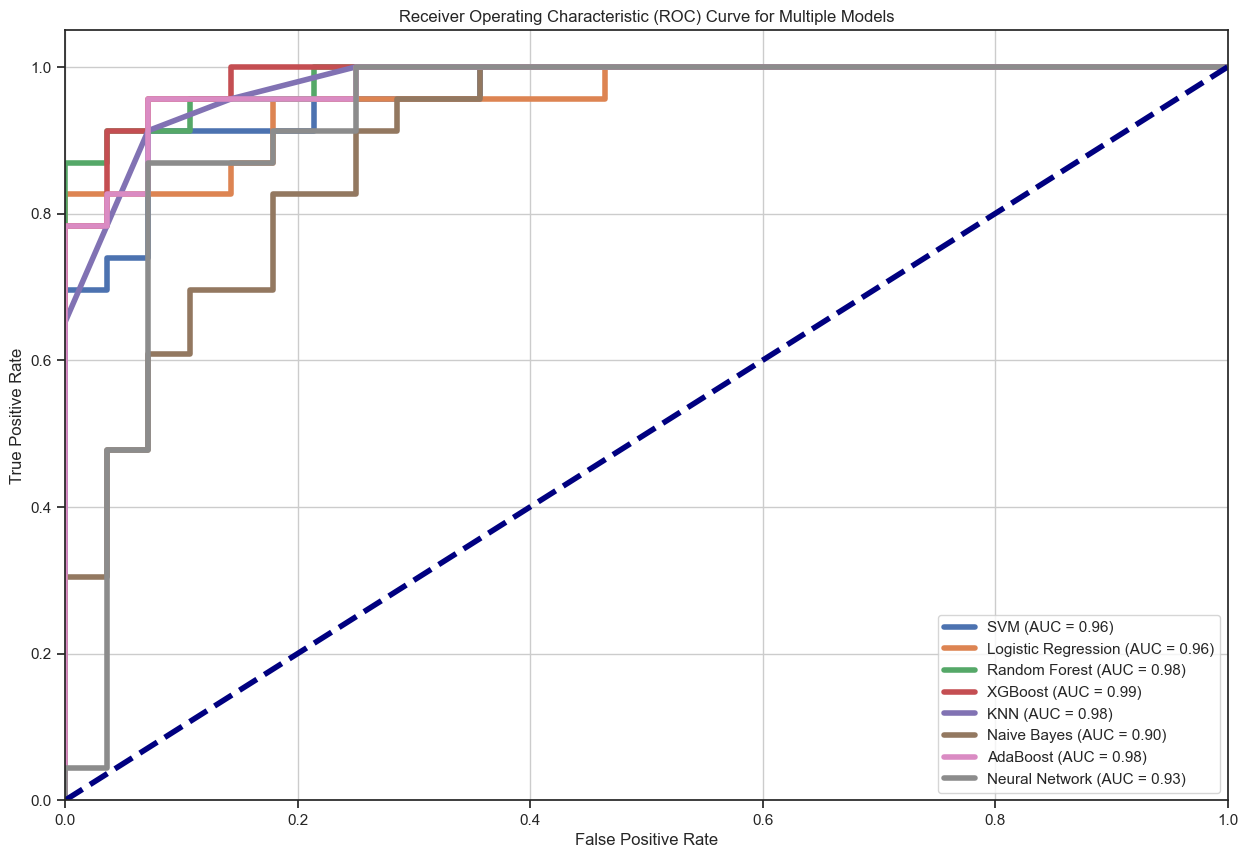

In [ ]:
roc_data = xgb_data
roc_data['regime_type'] = roc_data['political_regime'].apply(lambda x: 'Democracy' if 'Democracy' in x else 'Autocracy')
pd.set_option('display.max_rows', None)  # Show all rows

# Remove noisy features completely to avoid memory errors

X = roc_data.drop(columns=["political_regime", "regime_type"])  # Use only original features

# Split data into training and test sets (70% train, 30% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Optimized classifiers for memory efficiency

optimized_classifiers = {
    "SVM": OneVsRestClassifier(svm.SVC(kernel = "linear", probability = True, random_state = 0)),
    "Logistic Regression": LogisticRegression(solver = "liblinear", random_state = 0),
    "Random Forest": RandomForestClassifier(n_estimators = 50, max_depth = 5, max_features = 'sqrt', random_state = 0, n_jobs = 8),
    "XGBoost": XGBClassifier(eval_metric = "logloss", random_state = 0, max_depth = 3, n_jobs = 8),
    "KNN": KNeighborsClassifier(n_neighbors = 5, n_jobs = 8),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(n_estimators = 50, random_state = 0),
    "Neural Network": MLPClassifier(hidden_layer_sizes = (50,), max_iter = 100000, random_state = 0)
}

plt.figure(figsize = (15, 10))
lw = 4

# Train and plot ROC for each classifier

for name, classifier in optimized_classifiers.items():
    classifier.fit(X_train, y_train.ravel())  # Train classifier
    y_score = classifier.predict_proba(X_test)[:, 1] if hasattr(classifier, "predict_proba") else classifier.decision_function(X_test)
    
    # Compute ROC curve and ROC area

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot each ROC curve

    plt.plot(fpr, tpr, lw=lw, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot diagonal baseline

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve for Multiple Models")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()
